# Nigeria Standard Treatment Guidelines (NSTG) 2022 Dataset

## Description
This dataset contains a comprehensive collection of clinical guidelines processed and merged from the **Nigeria Standard Treatment Guidelines (NSTG) 2022**. It provides structured medical information for healthcare professionals, researchers, and developers building clinical decision support systems for the Nigerian context.

The dataset includes over 250 conditions, ranging from infectious diseases and maternal health to chronic non-communicable diseases.

## Files Included and Format
- **File:** `nigeria_clinical_guidelines_2022.json`
- **Format:** JSON Array (UTF-8 Encoded)
- **Status:** Validated, Merged, and Cleaned.

## Variables and Schema
Each condition object in the array contains the following fields:

| Field Name | Type | Description |
|------------|------|-------------|
| `condition_name` | String | The official name of the medical condition (e.g., "Abortion"). |
| `condition_slug` | String | A URL-friendly identifier for the condition. |
| `source` | String | The clinical source document (NSTG 2022). |
| `introduction` | String | An overview of the disease/condition pathology and prevalence. |
| `clinical_features` | List (Objects) | Symptoms and signs categorized by type (e.g., "General", "Symptomatic"). |
| `investigations` | List (Strings) | Recommended laboratory and radiological tests. |
| `treatment` | Object | Structured therapeutic advice split into `goals`, `non_drug`, and `drug` measures. |
| `differential_diagnoses` | List (Strings) | Alternative medical conditions with similar presentations. |
| `complications` | List (Strings) | Potential negative outcomes if left untreated. |
| `prevention` | List (Strings) | Methods for avoiding the condition or its hazards. |
| `prognosis` | String/Null | Expected outcome of the treatment. |

In [1]:
import numpy as np
from numpy import save
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.patches as mpatches
import seaborn as sns

from itertools import combinations
import warnings

import networkx as nx

from wordcloud import WordCloud

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
PALETTE = [
    "#2E86AB", "#F18F01", "#C73E1D", "#6A994E",
    "#A44A3F", "#3A86FF", "#8338EC", "#FF006E"
]

In [3]:
## To save the images
def save(fig, filename):
   
    fig.text(
        0.99, 0.01,
        '© [Adeoye Samuel] · https://github.com/Sammyregt/nstg-2022-clinical-guidelines-analysis.git · CC BY 4.0',
        fontsize=7, color='#AAAAAA',
        ha='right', va='bottom',
        style='italic'
    )
    fig.savefig(f"nstg_outputs/{filename}", bbox_inches="tight")
    plt.close(fig)

In [4]:
df = pd.read_json('nigeria_clinical_guidelines_2022.json')
df.head()

,condition_name,condition_slug,source,introduction,clinical_features,investigations,treatment,differential_diagnoses,complications,prevention,other_investigations,definitive_treatment,prognosis
0,Abortion,abortion,NSTG 2022,One of the leading causes of morbidity and mor...,"[{'type': 'Threatened Abortion', 'features': [...","[PCV or Hb estimation, Urinalysis, Ultrasound ...","{'goals': ['Restore haemostasis', 'Prevent/tre...","[Ectopic pregnancy, Hydatidiform mole]","[Endometritis, parametritis, peritonitis, haem...",[Promote personal and family understanding of ...,None,None,None
1,Acne Vulgaris,acne-vulgaris,NSTG 2022,One of the most common skin diseases. A disord...,"[{'type': 'General', 'features': ['Almost ever...","[Usually, none required, In the presence of un...","{'goals': ['Reduce severity of acne', 'Prevent...","[Acne rosacea, Dermatosis papulosa nigra, Stea...",[Psychosocial problems from cosmetic disfigure...,"[Avoid oil-based cosmetics, hair styling mouss...",None,None,None
2,Acute Abdomen,acute-abdomen,NSTG 2022,These are abdominal conditions causing sudden ...,"[{'type': 'Clinical Evaluation', 'features': [...",[Plain radiography of abdomen: Supine and upri...,"{'goals': ['Achieve good outcome', 'Prevent/mi...","[Detailed in Table 16.2, list of possible causes]",[],[],[Computed tomography when diagnostic confusion...,"[Once adequately resuscitated, proceed with de...",[Outcome and survival depend on early presenta...
3,Acute Anterior Uveitis,acute-anterior-uveitis,NSTG 2022,Inflammation of the iris and ciliary body. Usu...,"[{'type': 'Clinical Features', 'features': ['B...",[Chest radiograph to exclude sarcoidosis and t...,"{'goals': [], 'non_drug': [], 'drug': ['Cortic...","[Infective conjunctivitis, Acute iritis, Acute...","[Secondary glaucoma, Secondary cataracts]",[No real preventive measures],None,None,None
4,Acute Bronchitis,acute-bronchitis,NSTG 2022,An inflammation of the bronchial tubes. Common...,"[{'type': 'Clinical Features', 'features': ['C...","[Chest x-ray, Sputum tests, Quality sputum for...","{'goals': [], 'non_drug': [], 'drug': ['Antibi...","[Cough-variant asthma, Mycoplasma pneumonia, C...","[Pneumonia, Acute respiratory failure, Repeate...",[],None,None,None


In [5]:
#print the shape of the dataset and the column names
print(f"Shape of the dataset: {df.shape} ({df.shape[0]} rows and {df.shape[1]} columns)")
print(f"column names: {df.columns.tolist()}")

Shape of the dataset: (270, 13) (270 rows and 13 columns)
column names: ['condition_name', 'condition_slug', 'source', 'introduction', 'clinical_features', 'investigations', 'treatment', 'differential_diagnoses', 'complications', 'prevention', 'other_investigations', 'definitive_treatment', 'prognosis']


In [6]:
#checking the information about the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   condition_name          270 non-null    str   
 1   condition_slug          270 non-null    str   
 2   source                  270 non-null    str   
 3   introduction            270 non-null    str   
 4   clinical_features       270 non-null    object
 5   investigations          270 non-null    object
 6   treatment               270 non-null    object
 7   differential_diagnoses  270 non-null    object
 8   complications           270 non-null    object
 9   prevention              270 non-null    object
 10  other_investigations    12 non-null     object
 11  definitive_treatment    50 non-null     object
 12  prognosis               16 non-null     object
dtypes: object(9), str(4)
memory usage: 27.6+ KB


In [7]:
df.head(3)

,condition_name,condition_slug,source,introduction,clinical_features,investigations,treatment,differential_diagnoses,complications,prevention,other_investigations,definitive_treatment,prognosis
0,Abortion,abortion,NSTG 2022,One of the leading causes of morbidity and mor...,"[{'type': 'Threatened Abortion', 'features': [...","[PCV or Hb estimation, Urinalysis, Ultrasound ...","{'goals': ['Restore haemostasis', 'Prevent/tre...","[Ectopic pregnancy, Hydatidiform mole]","[Endometritis, parametritis, peritonitis, haem...",[Promote personal and family understanding of ...,None,None,None
1,Acne Vulgaris,acne-vulgaris,NSTG 2022,One of the most common skin diseases. A disord...,"[{'type': 'General', 'features': ['Almost ever...","[Usually, none required, In the presence of un...","{'goals': ['Reduce severity of acne', 'Prevent...","[Acne rosacea, Dermatosis papulosa nigra, Stea...",[Psychosocial problems from cosmetic disfigure...,"[Avoid oil-based cosmetics, hair styling mouss...",None,None,None
2,Acute Abdomen,acute-abdomen,NSTG 2022,These are abdominal conditions causing sudden ...,"[{'type': 'Clinical Evaluation', 'features': [...",[Plain radiography of abdomen: Supine and upri...,"{'goals': ['Achieve good outcome', 'Prevent/mi...","[Detailed in Table 16.2, list of possible causes]",[],[],[Computed tomography when diagnostic confusion...,"[Once adequately resuscitated, proceed with de...",[Outcome and survival depend on early presenta...


### Data Profiling and Cleaning

In [8]:
df_copy = df.copy()

#### Treatment variable

In [9]:
# working on the treatment column
df_copy['treatment'].head()

0    {'goals': ['Restore haemostasis', 'Prevent/tre...
1    {'goals': ['Reduce severity of acne', 'Prevent...
2    {'goals': ['Achieve good outcome', 'Prevent/mi...
3    {'goals': [], 'non_drug': [], 'drug': ['Cortic...
4    {'goals': [], 'non_drug': [], 'drug': ['Antibi...
Name: treatment, dtype: object

As given in the description
-  `treatment` -> Structured therapeutic advice split into `goals`, `non_drug`, and `drug` measures

In [10]:
# Extracting each sub key into seperate columns
df_copy['treatment_drug_list'] = df['treatment'].apply(
    lambda x: x.get("drug", []) if isinstance(x, dict) else []
)
df_copy['treatment_non_drug_list'] = df['treatment'].apply(
    lambda x: x.get("non_drug", []) if isinstance(x, dict) else []
)
df_copy['treatment_goal_list'] = df['treatment'].apply(
    lambda x: x.get("goals", []) if isinstance(x, dict) else []
)

df_copy.head(3)

,condition_name,condition_slug,source,introduction,clinical_features,investigations,treatment,differential_diagnoses,complications,prevention,other_investigations,definitive_treatment,prognosis,treatment_drug_list,treatment_non_drug_list,treatment_goal_list
0,Abortion,abortion,NSTG 2022,One of the leading causes of morbidity and mor...,"[{'type': 'Threatened Abortion', 'features': [...","[PCV or Hb estimation, Urinalysis, Ultrasound ...","{'goals': ['Restore haemostasis', 'Prevent/tre...","[Ectopic pregnancy, Hydatidiform mole]","[Endometritis, parametritis, peritonitis, haem...",[Promote personal and family understanding of ...,None,None,None,[IV line with wide-bore cannula and Normal sal...,"[Bed rest, Monitor vital signs, Avoidance of s...","[Restore haemostasis, Prevent/treat complicati..."
1,Acne Vulgaris,acne-vulgaris,NSTG 2022,One of the most common skin diseases. A disord...,"[{'type': 'General', 'features': ['Almost ever...","[Usually, none required, In the presence of un...","{'goals': ['Reduce severity of acne', 'Prevent...","[Acne rosacea, Dermatosis papulosa nigra, Stea...",[Psychosocial problems from cosmetic disfigure...,"[Avoid oil-based cosmetics, hair styling mouss...",None,None,None,[Comedonal acne: Tretinoin cream 0.025% or 0.0...,[Use non-irritating cleansing agents to reduce...,"[Reduce severity of acne, Prevent Complications]"
2,Acute Abdomen,acute-abdomen,NSTG 2022,These are abdominal conditions causing sudden ...,"[{'type': 'Clinical Evaluation', 'features': [...",[Plain radiography of abdomen: Supine and upri...,"{'goals': ['Achieve good outcome', 'Prevent/mi...","[Detailed in Table 16.2, list of possible causes]",[],[],[Computed tomography when diagnostic confusion...,"[Once adequately resuscitated, proceed with de...",[Outcome and survival depend on early presenta...,"[Commence broad spectrum, intravenous antibiot...","[Resuscitation and general measures, Rehydrati...","[Achieve good outcome, Prevent/minimize morbid..."


### Deriving count of items in each list for list columns

This done to see various approach that can be done

In [11]:
df_copy["n_drug_items"]     = df_copy["treatment_drug_list"].apply(len)
df_copy["n_nondrug_items"]  = df_copy["treatment_non_drug_list"].apply(len)
df_copy["n_investigations"] = df["investigations"].apply(len)
df_copy["n_complications"]  = df["complications"].apply(len)
df_copy["n_diff_dx"]        = df["differential_diagnoses"].apply(len)
df_copy["n_prevention"]     = df["prevention"].apply(len)
df_copy["n_goals"]          = df_copy["treatment_goal_list"].apply(len)

df_copy.head()

,condition_name,condition_slug,source,introduction,clinical_features,investigations,treatment,differential_diagnoses,complications,prevention,...,treatment_drug_list,treatment_non_drug_list,treatment_goal_list,n_drug_items,n_nondrug_items,n_investigations,n_complications,n_diff_dx,n_prevention,n_goals
0,Abortion,abortion,NSTG 2022,One of the leading causes of morbidity and mor...,"[{'type': 'Threatened Abortion', 'features': [...","[PCV or Hb estimation, Urinalysis, Ultrasound ...","{'goals': ['Restore haemostasis', 'Prevent/tre...","[Ectopic pregnancy, Hydatidiform mole]","[Endometritis, parametritis, peritonitis, haem...",[Promote personal and family understanding of ...,...,[IV line with wide-bore cannula and Normal sal...,"[Bed rest, Monitor vital signs, Avoidance of s...","[Restore haemostasis, Prevent/treat complicati...",6,6,8,2,2,3,3
1,Acne Vulgaris,acne-vulgaris,NSTG 2022,One of the most common skin diseases. A disord...,"[{'type': 'General', 'features': ['Almost ever...","[Usually, none required, In the presence of un...","{'goals': ['Reduce severity of acne', 'Prevent...","[Acne rosacea, Dermatosis papulosa nigra, Stea...",[Psychosocial problems from cosmetic disfigure...,"[Avoid oil-based cosmetics, hair styling mouss...",...,[Comedonal acne: Tretinoin cream 0.025% or 0.0...,[Use non-irritating cleansing agents to reduce...,"[Reduce severity of acne, Prevent Complications]",6,7,3,5,10,2,2
2,Acute Abdomen,acute-abdomen,NSTG 2022,These are abdominal conditions causing sudden ...,"[{'type': 'Clinical Evaluation', 'features': [...",[Plain radiography of abdomen: Supine and upri...,"{'goals': ['Achieve good outcome', 'Prevent/mi...","[Detailed in Table 16.2, list of possible causes]",[],[],...,"[Commence broad spectrum, intravenous antibiot...","[Resuscitation and general measures, Rehydrati...","[Achieve good outcome, Prevent/minimize morbid...",1,8,6,0,1,0,2
3,Acute Anterior Uveitis,acute-anterior-uveitis,NSTG 2022,Inflammation of the iris and ciliary body. Usu...,"[{'type': 'Clinical Features', 'features': ['B...",[Chest radiograph to exclude sarcoidosis and t...,"{'goals': [], 'non_drug': [], 'drug': ['Cortic...","[Infective conjunctivitis, Acute iritis, Acute...","[Secondary glaucoma, Secondary cataracts]",[No real preventive measures],...,[Corticosteroid drops: Betamethasone sodium ph...,[],[],3,0,3,2,3,1,0
4,Acute Bronchitis,acute-bronchitis,NSTG 2022,An inflammation of the bronchial tubes. Common...,"[{'type': 'Clinical Features', 'features': ['C...","[Chest x-ray, Sputum tests, Quality sputum for...","{'goals': [], 'non_drug': [], 'drug': ['Antibi...","[Cough-variant asthma, Mycoplasma pneumonia, C...","[Pneumonia, Acute respiratory failure, Repeate...",[],...,[Antibiotics - Amoxicillin 500 mg PO 8 hourly ...,[],[],3,0,4,3,4,0,0


### Deriving boolean Variables that can be meaningful


In [12]:
df_copy["has_introduction"]  = df_copy["introduction"].notna() & (df_copy["introduction"].str.strip() != "")
df_copy["has_prognosis"]     = df_copy["prognosis"].notna()
df_copy["has_prevention"]    = df_copy["n_prevention"] > 0
df_copy["has_complications"] = df_copy["n_complications"] > 0
df_copy["has_diff_dx"]       = df_copy["n_diff_dx"] > 0

df_copy.head(3)

,condition_name,condition_slug,source,introduction,clinical_features,investigations,treatment,differential_diagnoses,complications,prevention,...,n_investigations,n_complications,n_diff_dx,n_prevention,n_goals,has_introduction,has_prognosis,has_prevention,has_complications,has_diff_dx
0,Abortion,abortion,NSTG 2022,One of the leading causes of morbidity and mor...,"[{'type': 'Threatened Abortion', 'features': [...","[PCV or Hb estimation, Urinalysis, Ultrasound ...","{'goals': ['Restore haemostasis', 'Prevent/tre...","[Ectopic pregnancy, Hydatidiform mole]","[Endometritis, parametritis, peritonitis, haem...",[Promote personal and family understanding of ...,...,8,2,2,3,3,True,False,True,True,True
1,Acne Vulgaris,acne-vulgaris,NSTG 2022,One of the most common skin diseases. A disord...,"[{'type': 'General', 'features': ['Almost ever...","[Usually, none required, In the presence of un...","{'goals': ['Reduce severity of acne', 'Prevent...","[Acne rosacea, Dermatosis papulosa nigra, Stea...",[Psychosocial problems from cosmetic disfigure...,"[Avoid oil-based cosmetics, hair styling mouss...",...,3,5,10,2,2,True,False,True,True,True
2,Acute Abdomen,acute-abdomen,NSTG 2022,These are abdominal conditions causing sudden ...,"[{'type': 'Clinical Evaluation', 'features': [...",[Plain radiography of abdomen: Supine and upri...,"{'goals': ['Achieve good outcome', 'Prevent/mi...","[Detailed in Table 16.2, list of possible causes]",[],[],...,6,0,1,0,2,True,True,False,False,True


### Disease Category Classification

Grouping different diseases into different categories

In [13]:
CATEGORY_KEYWORDS = {
 

    # NEW CATEGORY 1 — Dental / Oral Health  (17 conditions)

    "Dental/Oral Health": [
        "gingivitis", "periodontitis", "dental caries", "pulpitis",
        "alveolar osteitis", "dry socket", "peri-apical abscess",
        "pericoronitis", "aphthous stomatitis", "oral thrush",
        "oral candidiasis", "sialadenitis", "temporomandibular",
        "necrotizing ulcerative", "plaque-induced", "gingival abscess",
        "salivary gland", "dental", "pulpitis", "pericoronitis",
    ],
 
    # NEW CATEGORY 2 — ENT: Ear, Nose & Throat  (16 conditions)

    "ENT (Ear, Nose & Throat)": [
        "otitis media", "otitis externa", "sinusitis", "tonsillitis",
        "pharyngitis", "sore throat", "epistaxis", "adenoid",
        "mastoiditis", "peritonsillar", "quinsy", "nasal allergy",
        "foreign bodies in the ear", "foreign bodies in the nose",
        "rhinolith", "wax in the ear", "vertigo", "dizziness",
    ],
 

    # NEW CATEGORY 3 — Haematological  (4 conditions)
    # Must be before Paediatric so "Sickle Cell Disease" is classified
    # as Haematological (its primary system) not Paediatric.

    "Haematological": [
        "anaemia", "anaemias", "blood transfusion",
        "sickle cell", "antiphospholipid syndrome",
        "vitamin k deficiency bleeding",
    ],
 

    # NEW CATEGORY 4 — Nutritional  (5 conditions)
    # Before Ophthalmology so "Xerophthalmia" (eye manifestation of
    # Vitamin A deficiency) is classified as Nutritional, not eye disease.

    "Nutritional": [
        "kwashiorkor", "marasmus", "vitamin a deficiency",
        "micronutrient deficien", "xerophthalmia",
    ],
 

    # NEW CATEGORY 5 — Geriatric  (3 conditions)

    "Geriatric": [
        "frailty", "elder mistreatment", "falls",
    ],
 

    # NEW CATEGORY 6 — Surgical / Emergency  (7 conditions)
    # Must be before Gastrointestinal so "Acute Abdomen" is classified
    # as Surgical not GI, and before Infectious so "Snake Bite" and
    # "Scorpion Sting" aren't pulled into Infectious/Tropical.

    "Surgical/Emergency": [
        "surgical care", "surgical site infection",
        "transfusion in surgery", "snake bite",
        "scorpion sting", "foreign bodies in the airways",
        "acute abdomen",
    ],
 

    # EXISTING CATEGORIES — all expanded with new keywords

 
    "Infectious/Tropical": [
        "malaria", "tuberculosis", "hiv", "cholera", "typhoid",
        "leprosy", "meningitis", "hepatitis", "lassa", "dengue",
        "amoebiasis", "dysentery", "brucellosis", "chlamydial",
        "gonorrhea", "syphilis", "chancroid", "schistosomiasis",
        "filariasis", "trypanosomiasis", "rabies", "tetanus",
        #  viral infections
        "coronavirus", "covid-19", "measles", "rubeola",
        "varicella", "chickenpox", "poliomyelitis", "herpes zoster",
        "molluscum contagiosum", "viral warts", "verrucae",
        "impetigo contagiosa",
        # parasitic / tropical
        "guinea worm", "dracunculiasis", "helminthiasis",
        "onchocerciasis", "river blindness", "giardiasis",
        # STIs (not covered by Maternal/Reproductive)
        "lymphogranuloma venereum", "granuloma inguinale",
        "donovanosis", "trichomoniasis",
        # other infections
        "infective endocarditis", "food poisoning", "fevers",
    ],
 
    "Maternal/Reproductive": [
        "abortion", "pregnancy", "antenatal", "eclampsia",
        "labour", "postpartum", "vaginosis", "vulvovaginal",
        "menorrhagia", "fibroid", "endometriosis",
        "hyperemesis gravidarum", "pelvic inflammatory",
        "vulvo-vaginal", "erectile dysfunction",
        "male infertility", "rape",
    ],
 
    "Cardiovascular": [

        "cardiac", "heart", "hypertension", "angina", "arrhythmia",
        "cardiomyopathy", "coronary", "venous thrombosis",
        "cardiomyopathies", "myocarditis", "pericarditis",
        "peripheral vascular", "deep vein thrombosis",
        "rheumatic fever", "syncope", "chest pain",
        "endocarditis",
    ],
 
    "Respiratory": [

        "asthma", "bronchitis", "pneumonia", "bronchiectasis",
        "obstructive", "epiglottitis", "rhinitis", "pulmonary",
        "cough", "dyspnoea", "lung abscess",
    ],
 
    "Neurological/Mental": [

        "epilepsy", "anxiety", "bipolar", "schizophrenia",
        "depression", "dementia", "migraine", "alcohol dependence",
        "seizures", "stroke", "cerebrovascular", "parkinsonism",
        "delirium", "headache", "insomnia", "panic disorder",
        "paralyz", "unconscious",
    ],
 
    "Endocrine/Metabolic": [

        "diabetes", "thyroid", "obesity", "gout", "hyperlipidaemia",
        "adrenal", "osteoporosis", "metabolic",
        "cushing", "thyrotoxicosis", "diabetic foot",
        "hyperglycemia in a child", "hypoglycemia in a child",
        "dubin-johnson",
    ],
 
    "Gastrointestinal": [

        "diarrhoea", "peptic ulcer", "pancreatitis", "appendicitis",
        "cholestasis", "bowel", "colitis",
        "constipation", "gastritis", "haemorrhoid",
        "jaundice", "liver cirrhosis", "foreign body impaction",
        "liver abscess",
    ],
 
    "Renal/Urological": [

        "kidney", "renal", "urinary", "prostatic", "nephrotic",
        "prostatitis", "urethral", "torsion of the testis",
        "empty scrotum", "priapism", "posterior urethral",
    ],
 
    "Oncology": [

        "cancer", "carcinoma", "leukaemia", "lymphoma", "myeloma", "tumour",
        "neoplasm", "sarcoma",
    ],
 
    "Paediatric": [

        "newborn", "neonatal", "juvenile",
        # neonatal emergencies (checked after Haematological
        # so sickle cell goes to Haematological, not Paediatric)
        "asphyxia", "asphyxiated",
        "ophthalmia neonatorum",
        "apnea in a child",
    ],
 
    "Dermatological": [

        "acne", "eczema", "dermatitis", "cellulitis", "psoriasis", "urticaria",
        # fungal / parasitic skin
        "scabies", "tinea", "dermatophyte", "pityriasis",
        "cutaneous larva", "pediculosis", "lice", "myiasis",
        # inflammatory / other skin
        "lichen planus", "furunculosis", "boils",
        "decubitus", "pressure ulcer",
        "vitiligo", "pruritus",
    ],
 
    "Ophthalmology": [
        "uveitis", "keratitis", "cataract", "conjunctivitis",
        "glaucoma", "retinal",
        "ophthalmia", "scleritis", "episcleritis",
        "stye", "hordeolum", "red eye", "trachoma",
    ],
 
    "Musculoskeletal": [
        "arthritis", "osteoarthritis", "back pain", "ankylosis",
        "lupus", "rheumatoid",
        "sjogren", "scleroderma", "systemic sclerosis",
        "myopathies", "idiopathic inflammatory",
        "rheumatic and musculoskeletal",
    ],
}

In [14]:
def assign_category(name: str) -> str:
    name_lower = name.lower()
    for category, keywords in CATEGORY_KEYWORDS.items():
        if any(kw in name_lower for kw in keywords):
            return category
    return "Other (Unclassifiable)"

df_copy["category"] = df_copy["condition_name"].apply(assign_category)
df_copy["category"].value_counts()

category
Infectious/Tropical         41
Dermatological              20
Dental/Oral Health          18
Oncology                    18
Maternal/Reproductive       16
Cardiovascular              16
ENT (Ear, Nose & Throat)    16
Neurological/Mental         16
Endocrine/Metabolic         15
Gastrointestinal            13
Respiratory                 12
Renal/Urological            12
Haematological              11
Musculoskeletal             11
Ophthalmology               10
Surgical/Emergency           8
Paediatric                   7
Nutritional                  5
Geriatric                    3
Other (Unclassifiable)       2
Name: count, dtype: int64

### Known Drug Detection

- Flatten the drug_list to a single string per row, then check for each
- known drug name. Returns a list of matched drug names per condition.

In [15]:
KNOWN_DRUGS = [
    "metronidazole","amoxicillin","paracetamol","ciprofloxacin","azithromycin",
    "penicillin","doxycycline","chloroquine","artemether","lumefantrine",
    "artesunate","quinine","erythromycin","ampicillin","gentamicin",
    "cotrimoxazole","fluconazole","ibuprofen","aspirin","prednisolone",
    "dexamethasone","amlodipine","enalapril","lisinopril","metformin",
    "insulin","furosemide","spironolactone","atenolol","nifedipine",
    "ceftriaxone","cefixime","vancomycin","rifampicin","isoniazid",
    "pyrazinamide","ethambutol","phenytoin","valproate","diazepam",
    "phenobarbitone","omeprazole","ranitidine","metoclopramide","ondansetron",
    "salbutamol","aminophylline","theophylline","hydrocortisone","benzylpenicillin",
    "albendazole","mebendazole","ivermectin","praziquantel","haloperidol",
    "chlorpromazine","risperidone","diclofenac","tramadol","morphine",
    "misoprostol","oxytocin","heparin","warfarin","digoxin","amiodarone",
    "simvastatin","hydroxychloroquine","sulfadoxine","pyrimethamine",
    "tetracycline","streptomycin","clarithromycin","levofloxacin",
    "cloxacillin","flucloxacillin",
]

In [16]:
def detect_drugs(drug_entries):
    """Given a list of treatment drug strings, return matched known drugs."""
    text = " ".join(drug_entries).lower()
    return [d for d in KNOWN_DRUGS if d in text]

In [17]:
df_copy["detected_drugs"] = df_copy["treatment_drug_list"].apply(detect_drugs)
df_copy["n_detected_drugs"] = df_copy["detected_drugs"].apply(len)

df_copy.head(3)

,condition_name,condition_slug,source,introduction,clinical_features,investigations,treatment,differential_diagnoses,complications,prevention,...,n_prevention,n_goals,has_introduction,has_prognosis,has_prevention,has_complications,has_diff_dx,category,detected_drugs,n_detected_drugs
0,Abortion,abortion,NSTG 2022,One of the leading causes of morbidity and mor...,"[{'type': 'Threatened Abortion', 'features': [...","[PCV or Hb estimation, Urinalysis, Ultrasound ...","{'goals': ['Restore haemostasis', 'Prevent/tre...","[Ectopic pregnancy, Hydatidiform mole]","[Endometritis, parametritis, peritonitis, haem...",[Promote personal and family understanding of ...,...,3,3,True,False,True,True,True,Maternal/Reproductive,"[misoprostol, oxytocin]",2
1,Acne Vulgaris,acne-vulgaris,NSTG 2022,One of the most common skin diseases. A disord...,"[{'type': 'General', 'features': ['Almost ever...","[Usually, none required, In the presence of un...","{'goals': ['Reduce severity of acne', 'Prevent...","[Acne rosacea, Dermatosis papulosa nigra, Stea...",[Psychosocial problems from cosmetic disfigure...,"[Avoid oil-based cosmetics, hair styling mouss...",...,2,2,True,False,True,True,True,Dermatological,"[doxycycline, erythromycin, prednisolone, spir...",6
2,Acute Abdomen,acute-abdomen,NSTG 2022,These are abdominal conditions causing sudden ...,"[{'type': 'Clinical Evaluation', 'features': [...",[Plain radiography of abdomen: Supine and upri...,"{'goals': ['Achieve good outcome', 'Prevent/mi...","[Detailed in Table 16.2, list of possible causes]",[],[],...,0,2,True,True,False,False,True,Surgical/Emergency,[],0


In [18]:
print(df_copy.describe().round(2).to_string())

       n_drug_items  n_nondrug_items  n_investigations  n_complications  n_diff_dx  n_prevention  n_goals  n_detected_drugs
count        270.00           270.00            270.00           270.00     270.00        270.00   270.00            270.00
mean           4.61             2.67              4.19             2.87       2.80          1.68     1.90              1.41
std            4.32             3.11              3.71             3.11       3.44          2.32     1.71              1.64
min            0.00             0.00              0.00             0.00       0.00          0.00     0.00              0.00
25%            2.00             0.00              1.00             0.00       0.00          0.00     0.00              0.00
50%            4.00             2.00              3.00             2.00       2.00          1.00     2.00              1.00
75%            6.00             4.00              6.00             4.00       4.00          2.00     3.00              2.00
max     

In [19]:
df_copy.isnull().sum()

condition_name               0
condition_slug               0
source                       0
introduction                 0
clinical_features            0
investigations               0
treatment                    0
differential_diagnoses       0
complications                0
prevention                   0
other_investigations       258
definitive_treatment       220
prognosis                  254
treatment_drug_list          0
treatment_non_drug_list      0
treatment_goal_list          0
n_drug_items                 0
n_nondrug_items              0
n_investigations             0
n_complications              0
n_diff_dx                    0
n_prevention                 0
n_goals                      0
has_introduction             0
has_prognosis                0
has_prevention               0
has_complications            0
has_diff_dx                  0
category                     0
detected_drugs               0
n_detected_drugs             0
dtype: int64

In [20]:
# Build completeness table using DataFrame boolean flags and counts.
# pd.Series for non-list columns, .apply(len)>0 for list columns.
n = len(df_copy)
completeness = pd.DataFrame({
    "Field": [
        "Treatment","Introduction","Clinical Features",
        "Investigations","Complications","Differential Diagnoses",
        "Prevention","Prognosis"
    ],
    "Filled": [
        n,                          
        df_copy["has_introduction"].sum(),
        df_copy["clinical_features"].apply(lambda x: len(x) > 0).sum(),
        df_copy["n_investigations"].gt(0).sum(),
        df_copy["has_complications"].sum(),
        df_copy["has_diff_dx"].sum(),
        df_copy["has_prevention"].sum(),
        df_copy["has_prognosis"].sum(),
    ]
})
completeness["Completeness_pct"] = (completeness["Filled"] / n * 100).round(1)
completeness["Missing"] = n - completeness["Filled"]
completeness = completeness.sort_values("Completeness_pct", ascending=True).reset_index(drop=True)
print(completeness[["Field","Filled","Missing","Completeness_pct"]].to_string(index=False)) 

                 Field  Filled  Missing  Completeness_pct
             Prognosis      16      254               5.9
            Prevention     155      115              57.4
Differential Diagnoses     166      104              61.5
         Complications     184       86              68.1
        Investigations     232       38              85.9
     Clinical Features     257       13              95.2
          Introduction     264        6              97.8
             Treatment     270        0             100.0


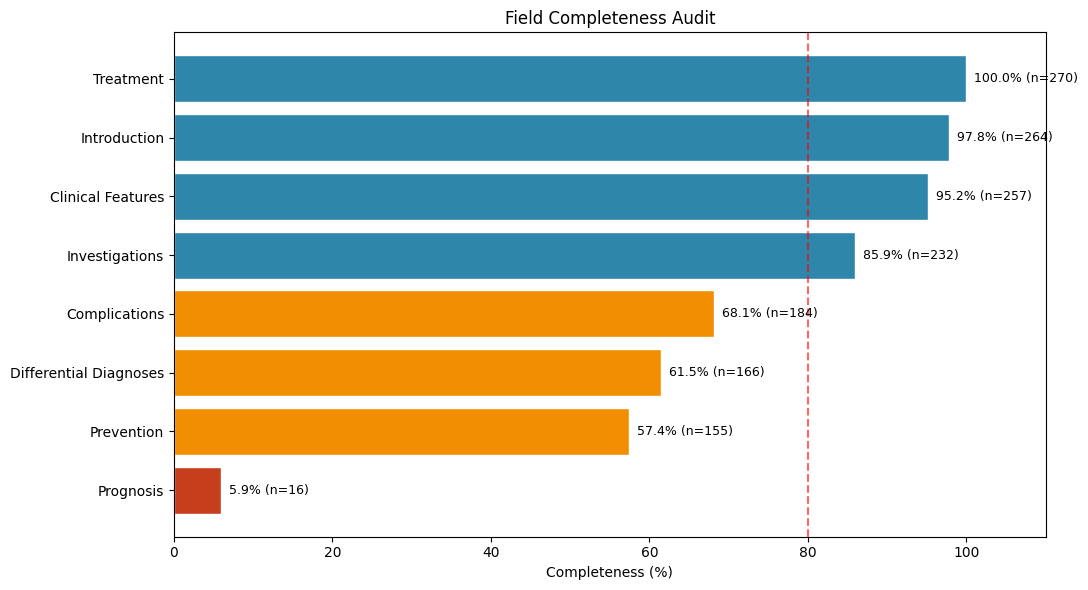

In [21]:
fig, ax = plt.subplots(figsize=(11, 6))

# Colors (simplified)
def get_color(v):
    if v >= 80:
        return "#2E86AB"
    elif v >= 50:
        return "#F18F01"
    return "#C73E1D"

colors = completeness["Completeness_pct"].apply(get_color)

# Plot
bars = ax.barh(
    completeness["Field"],
    completeness["Completeness_pct"],
    color=colors,
    edgecolor="white"
)

ax.set(
    xlim=(0, 110),
    xlabel="Completeness (%)",
    title="Field Completeness Audit"
)

# Labels (simplified loop)
for bar, filled, pct in zip(
    bars,
    completeness["Filled"],
    completeness["Completeness_pct"]
):
    ax.text(
        bar.get_width() + 1,
        bar.get_y() + bar.get_height()/2,
        f"{pct}% (n={filled})",
        va="center",
        fontsize=9
    )

# Reference line
ax.axvline(80, linestyle="--", color="red", alpha=0.6)

plt.tight_layout()
#plt.savefig("nstg_outputs/fig01_completeness.png")
plt.show()
save(fig, "fig01_completeness.png")

#### inference
- Treatment data is 100% complete — fully usable
- Introduction and clinical features are >95% complete.
- However, Prognosis is critically sparse (5.9%), meaning it should be excluded from any outcome-based analysis.
-  Prevention is only 57.4% complete, indicating a documentation gap in preventive healthcare guidance.


### Disease Category Distribution

In [22]:
df_copy.head(2)

,condition_name,condition_slug,source,introduction,clinical_features,investigations,treatment,differential_diagnoses,complications,prevention,...,n_prevention,n_goals,has_introduction,has_prognosis,has_prevention,has_complications,has_diff_dx,category,detected_drugs,n_detected_drugs
0,Abortion,abortion,NSTG 2022,One of the leading causes of morbidity and mor...,"[{'type': 'Threatened Abortion', 'features': [...","[PCV or Hb estimation, Urinalysis, Ultrasound ...","{'goals': ['Restore haemostasis', 'Prevent/tre...","[Ectopic pregnancy, Hydatidiform mole]","[Endometritis, parametritis, peritonitis, haem...",[Promote personal and family understanding of ...,...,3,3,True,False,True,True,True,Maternal/Reproductive,"[misoprostol, oxytocin]",2
1,Acne Vulgaris,acne-vulgaris,NSTG 2022,One of the most common skin diseases. A disord...,"[{'type': 'General', 'features': ['Almost ever...","[Usually, none required, In the presence of un...","{'goals': ['Reduce severity of acne', 'Prevent...","[Acne rosacea, Dermatosis papulosa nigra, Stea...",[Psychosocial problems from cosmetic disfigure...,"[Avoid oil-based cosmetics, hair styling mouss...",...,2,2,True,False,True,True,True,Dermatological,"[doxycycline, erythromycin, prednisolone, spir...",6


                    Category  Count  Percentage
0        Infectious/Tropical     41        15.2
1             Dermatological     20         7.4
2         Dental/Oral Health     18         6.7
3                   Oncology     18         6.7
4      Maternal/Reproductive     16         5.9
5             Cardiovascular     16         5.9
6   ENT (Ear, Nose & Throat)     16         5.9
7        Neurological/Mental     16         5.9
8        Endocrine/Metabolic     15         5.6
9           Gastrointestinal     13         4.8
10               Respiratory     12         4.4
11          Renal/Urological     12         4.4
12            Haematological     11         4.1
13           Musculoskeletal     11         4.1
14             Ophthalmology     10         3.7
15        Surgical/Emergency      8         3.0
16                Paediatric      7         2.6
17               Nutritional      5         1.9
18                 Geriatric      3         1.1
19    Other (Unclassifiable)      2     

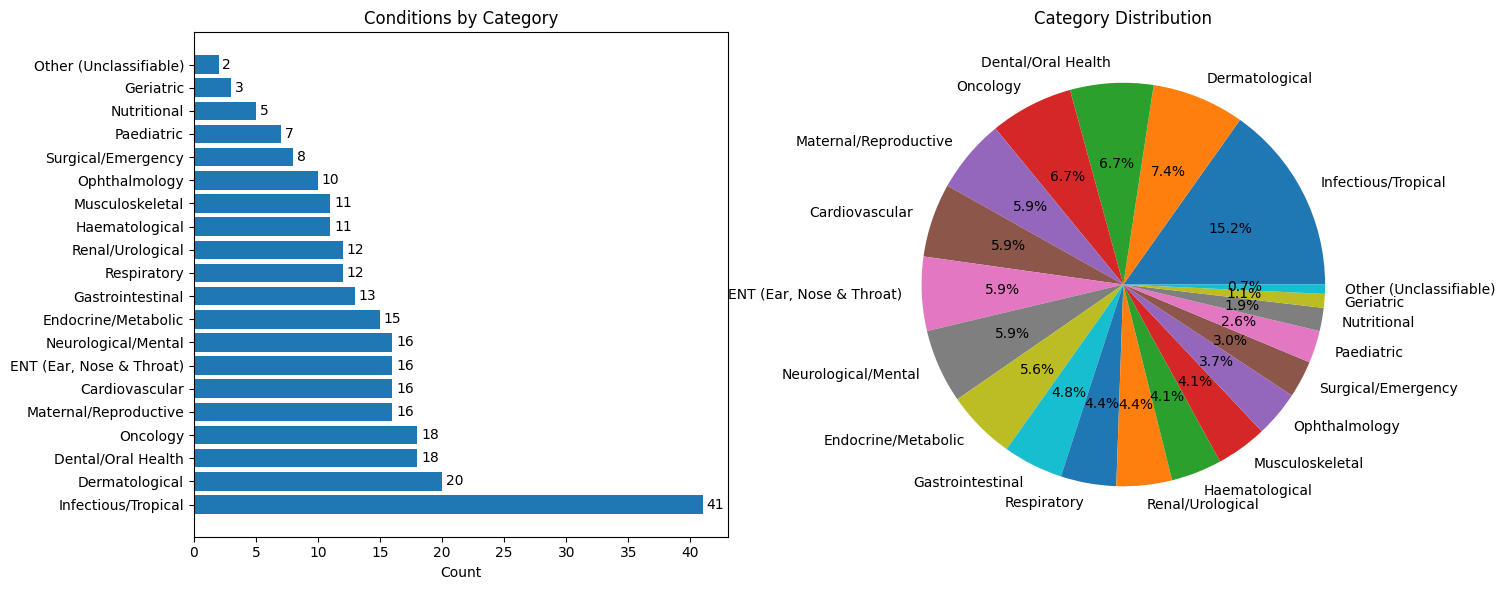

In [23]:
cat_counts = df_copy["category"].value_counts().reset_index()
cat_counts.columns = ["Category", "Count"]
cat_counts["Percentage"] = (cat_counts["Count"] / len(df_copy) * 100).round(1)

print(cat_counts)

# ── Plot ─────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
bars = ax1.barh(cat_counts["Category"], cat_counts["Count"])
# Add numbers outside the bars
for bar in bars:
    width = bar.get_width()
    
    ax1.text(
        width + 0.3,                     
        bar.get_y() + bar.get_height()/2,
        str(int(width)),                
        va="center"
    )

ax1.set_title("Conditions by Category")
ax1.set_xlabel("Count")

# Pie chart
ax2.pie(cat_counts["Count"], labels=cat_counts["Category"], autopct="%1.1f%%")
ax2.set_title("Category Distribution")

plt.tight_layout()
#plt.savefig("nstg_outputs/fig02_category_distribution.png")
plt.show()
save(fig, "fig02_category_distribution.png")

### Insights

### 1. Infectious/Tropical Diseases Lead (15.2%)
Infectious/Tropical diseases (n = 41) remain the largest category, reflecting Nigeria’s continued burden of communicable diseases such as malaria, TB, and HIV.

---

### 2. Strong Presence of Dermatology, Oncology & Oral Health (6–7%)
Dermatological (7.4%), Dental/Oral Health (6.7%), and Oncology (6.7%) are among the top non-infectious categories, highlighting significant outpatient and chronic disease workloads.

---

### 3. Broad Mid-Tier Clinical Coverage (4–6%)
A large cluster of categories fall within a narrow range (~5–6%), including:
- Cardiovascular  
- Neurological/Mental  
- ENT  
- Maternal/Reproductive  
- Endocrine/Metabolic  

This suggests **balanced guideline coverage across major specialties**.

---

### 4. Low Representation Categories (<3%)
Several important areas are underrepresented:
- Paediatric (2.6%)
- Nutritional (1.9%)
- Geriatric (1.1%)
- Unclassifiable (0.7%)

These represent potential **policy and guideline gaps**, especially in ageing and preventive care.

---

## 📌 Summary
The NSTG 2022 distribution reflects a **mixed disease burden system**, where Infectious/Tropical diseases remain dominant but **non-communicable diseases collectively form the majority of clinical coverage**. While specialty coverage is fairly balanced, **geriatrics and nutrition remain critically underrepresented**, indicating key areas for future guideline expansion.

In [24]:
df_copy[df_copy['category'] == 'Infectious/Tropical'].groupby('condition_name').size().sort_values(ascending=False)

condition_name
Malaria in the Newborn                                        2
Poliomyelitis                                                 2
Amoebiasis                                                    1
Chlamydial Infection (Other Than Lymphogranuloma Venereum)    1
Cholera                                                       1
Bacillary Dysentery                                           1
Chancroid (Ulcus Molle, Soft Chancre)                         1
Fevers                                                        1
Coronavirus Disease (COVID-19)                                1
Gonorrhea                                                     1
Food Poisoning                                                1
Gonorrhea in Females                                          1
Granuloma Inguinale (Donovanosis Granuloma Venereum)          1
Guinea Worm Disease (Dracunculiasis)                          1
Giardiasis                                                    1
Helminthiasis            

### Drug Frequency Analysis

In [25]:
df_copy.head(2)

,condition_name,condition_slug,source,introduction,clinical_features,investigations,treatment,differential_diagnoses,complications,prevention,...,n_prevention,n_goals,has_introduction,has_prognosis,has_prevention,has_complications,has_diff_dx,category,detected_drugs,n_detected_drugs
0,Abortion,abortion,NSTG 2022,One of the leading causes of morbidity and mor...,"[{'type': 'Threatened Abortion', 'features': [...","[PCV or Hb estimation, Urinalysis, Ultrasound ...","{'goals': ['Restore haemostasis', 'Prevent/tre...","[Ectopic pregnancy, Hydatidiform mole]","[Endometritis, parametritis, peritonitis, haem...",[Promote personal and family understanding of ...,...,3,3,True,False,True,True,True,Maternal/Reproductive,"[misoprostol, oxytocin]",2
1,Acne Vulgaris,acne-vulgaris,NSTG 2022,One of the most common skin diseases. A disord...,"[{'type': 'General', 'features': ['Almost ever...","[Usually, none required, In the presence of un...","{'goals': ['Reduce severity of acne', 'Prevent...","[Acne rosacea, Dermatosis papulosa nigra, Stea...",[Psychosocial problems from cosmetic disfigure...,"[Avoid oil-based cosmetics, hair styling mouss...",...,2,2,True,False,True,True,True,Dermatological,"[doxycycline, erythromycin, prednisolone, spir...",6


In [26]:
drug_freq = (
    df_copy.explode("detected_drugs")
      .dropna(subset=["detected_drugs"])
      ["detected_drugs"]
      .value_counts()
      .reset_index()
)

drug_freq.columns = ["Drug", "Conditions"]
drug_freq["Breadth_pct"] = (drug_freq["Conditions"] / n * 100).round(1)

# Show top 25
top25 = drug_freq.head(25)
print("Top 25 drugs:")
print(top25.to_string(index=True))

Top 25 drugs:
              Drug  Conditions  Breadth_pct
0      amoxicillin          26          9.6
1     prednisolone          23          8.5
2      paracetamol          22          8.1
3     erythromycin          18          6.7
4    metronidazole          18          6.7
5      ceftriaxone          15          5.6
6         diazepam          12          4.4
7   hydrocortisone          12          4.4
8        ibuprofen          11          4.1
9       gentamicin          10          3.7
10      penicillin          10          3.7
11    tetracycline           9          3.3
12         aspirin           9          3.3
13      diclofenac           9          3.3
14      furosemide           9          3.3
15   ciprofloxacin           9          3.3
16         insulin           8          3.0
17     doxycycline           7          2.6
18        warfarin           7          2.6
19         heparin           6          2.2
20    azithromycin           6          2.2
21  phenobarbitone

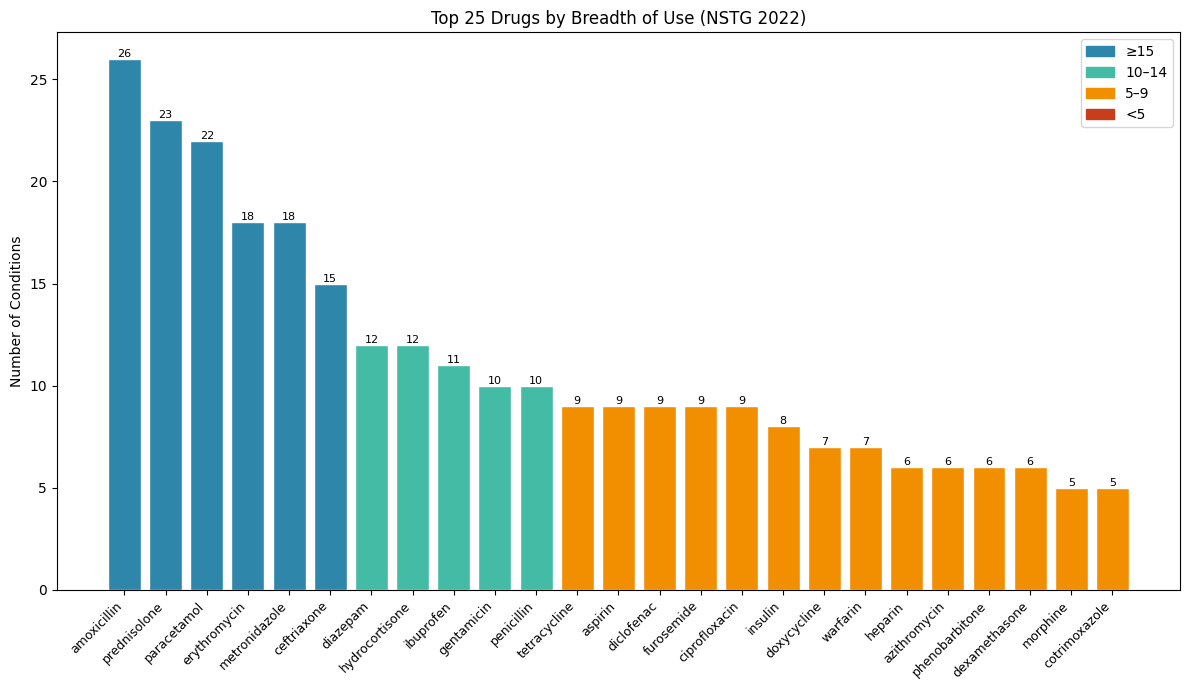

In [27]:
fig, ax = plt.subplots(figsize=(12, 7))

# Color logic (simplified but same meaning)
def get_color(v):
    if v >= 15:
        return "#2E86AB"
    elif v >= 10:
        return "#44BBA4"
    elif v >= 5:
        return "#F18F01"
    else:
        return "#C73E1D"

colors = [get_color(v) for v in top25["Conditions"]]

# Bar chart
bars = ax.bar(top25["Drug"], top25["Conditions"],
              color=colors, edgecolor="white")

# Labels
ax.set_title("Top 25 Drugs by Breadth of Use (NSTG 2022)")
ax.set_ylabel("Number of Conditions")
ax.set_xticklabels(top25["Drug"], rotation=45, ha="right", fontsize=9)

# Value labels on bars
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        int(bar.get_height()),
        ha="center",
        va="bottom",
        fontsize=8
    )

# Legend (simplified)
ax.legend(handles=[
    mpatches.Patch(color="#2E86AB", label="≥15"),
    mpatches.Patch(color="#44BBA4", label="10–14"),
    mpatches.Patch(color="#F18F01", label="5–9"),
    mpatches.Patch(color="#C73E1D", label="<5")
])

plt.tight_layout()
#plt.savefig("nstg_outputs/fig03_drug_frequency.png")
plt.show()
save(fig, "fig03_drug_frequency.png")

### Drug Frequency Analysis

In [28]:
TOP_N = 20
top_drugs = drug_freq.head(TOP_N)["Drug"].tolist()

co_matrix = pd.DataFrame(0, index=top_drugs, columns=top_drugs)

for drugs in df_copy["detected_drugs"]:
    if not isinstance(drugs, list):
        continue

    filtered = [d for d in drugs if d in top_drugs]

    for a, b in combinations(filtered, 2):
        co_matrix.loc[a, b] += 1
        co_matrix.loc[b, a] += 1

print(f"  Co-occurrence matrix: {co_matrix.shape}")
print(f"  Max co-occurrence: {co_matrix.values.max()} conditions")

  Co-occurrence matrix: (20, 20)
  Max co-occurrence: 9 conditions


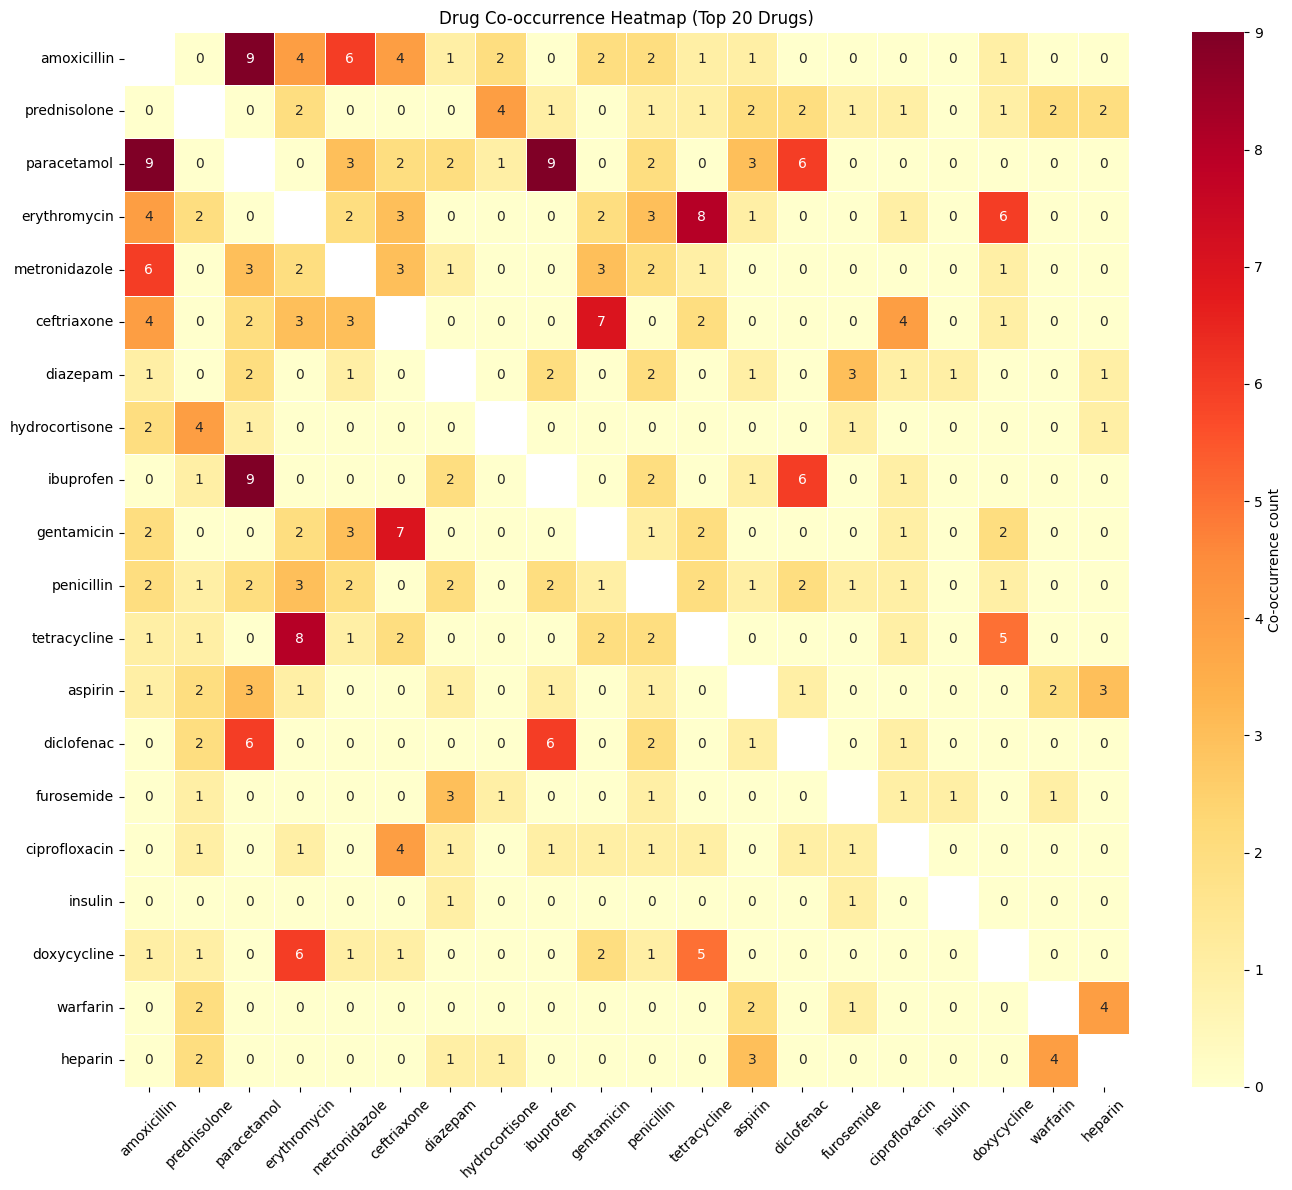

In [29]:
fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    co_matrix,
    mask=np.eye(TOP_N, dtype=bool),
    cmap="YlOrRd",
    annot=True,
    fmt="d",
    linewidths=0.5,
    cbar_kws={"label": "Co-occurrence count"},
    ax=ax
)

ax.set_title("Drug Co-occurrence Heatmap (Top 20 Drugs)")
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
#plt.savefig("nstg_outputs/fig04_drug_cooccurrence_heatmap.png")
plt.show()
save(fig, "fig04_drug_cooccurrence_heatmap.png")

### Key Findings

#### 1. Strongest Drug Pair: Amoxicillin + Paracetamol
- Highest co-occurrence: **9 conditions**
- Represents a standard **infection + symptom management strategy**
- Amoxicillin treats bacterial infections while paracetamol manages pain and fever

➡️ This confirms a frontline outpatient treatment model combining antibiotics with analgesics.

---

#### 2. Strong Antibiotic Pairing Patterns
Frequent antibiotic combinations include:
- Amoxicillin + Metronidazole (6)
- Tetracycline + Erythromycin (8)
- Ceftriaxone + Gentamicin (7)

➡️ Indicates:
- High use of **broad-spectrum or combination antibiotic therapy**
- Empirical treatment approaches for mixed or uncertain infections

---

#### 3. Pain and Inflammation Cluster
- Paracetamol + Ibuprofen (9)
- Paracetamol + Diclofenac (6)

➡️ Suggests:
- Strong overlap in **pain, fever, and inflammatory condition management**
- Multiple analgesic options used interchangeably depending on severity

---

#### 4. Cardiovascular & Coagulation Relationships
- Warfarin + Heparin (4)
- Warfarin + Aspirin (2)

➡️ Reflects:
- Standard anticoagulation strategy (acute → long-term management)
- Structured cardiovascular treatment pathways

---

#### 5. Cross-System Drug Pairings
Examples:
- Diazepam + Paracetamol (2)
- Furosemide + Diazepam (3)
- Hydrocortisone + Prednisolone (4)

➡️ Indicates:
- Multi-system treatment scenarios
- Drugs used across different clinical domains

---

### ⚠️ Key Insight
The network is **strongly antibiotic-centered**, meaning:

- Antibiotics form the main treatment hub
- Symptom-relief drugs (paracetamol, NSAIDs) act as universal companions
- Specialty drugs (insulin, warfarin, heparin) are more isolated

---

### 📌 Summary
The NSTG 2022 drug co-occurrence network reveals a **hub-and-spoke prescribing structure**, dominated by antibiotics and supported by analgesics and anti-inflammatory drugs. This reflects a **syndromic, empirical treatment approach common in primary healthcare settings**, shaped by a high infectious disease burden and standardized treatment guidelines.

### DRUG–DISEASE NETWORK GRAPH

In [30]:
# ── 1. Top drugs ───────────────────────────────────────────────────────────────
top_drugs = drug_freq.head(15).set_index("Drug")["Conditions"].to_dict()

# ── 2. Create graph ───────────────────────────────────────────────────────────
G = nx.Graph()

# Add drug nodes
for drug, freq in top_drugs.items():
    G.add_node(drug, type="drug", size=600 + freq * 50)

# ── 3. Add condition nodes + edges ────────────────────────────────────────────
for _, row in df_copy.iterrows():

    drugs = row.get("detected_drugs", [])
    if not isinstance(drugs, list):
        continue

    matched = [d for d in drugs if d in top_drugs]
    if not matched:
        continue

    condition = row["condition_name"][:35]
    category = row.get("category", "Other")

    G.add_node(condition, type="condition", category=category)

    for drug in matched:
        G.add_edge(drug, condition)

print(f"Nodes: {G.number_of_nodes()} | Edges: {G.number_of_edges()}")

Nodes: 125 | Edges: 197


In [31]:
# ── 4. Colors ────────────────────────────────────────────────────────────────
categories = df_copy["category"].dropna().unique()
category_colors = {
    cat: PALETTE[i % len(PALETTE)] for i, cat in enumerate(categories)
}
category_colors["Other"] = "#AAAAAA"

node_colors = []
node_sizes = []

for n in G.nodes:
    data = G.nodes[n]

    if data.get("type") == "drug":
        node_colors.append("#2E86AB")
        node_sizes.append(data["size"])
    else:
        node_colors.append(
            category_colors.get(data.get("category", "Other"), "#AAAAAA")
        )
        node_sizes.append(150)


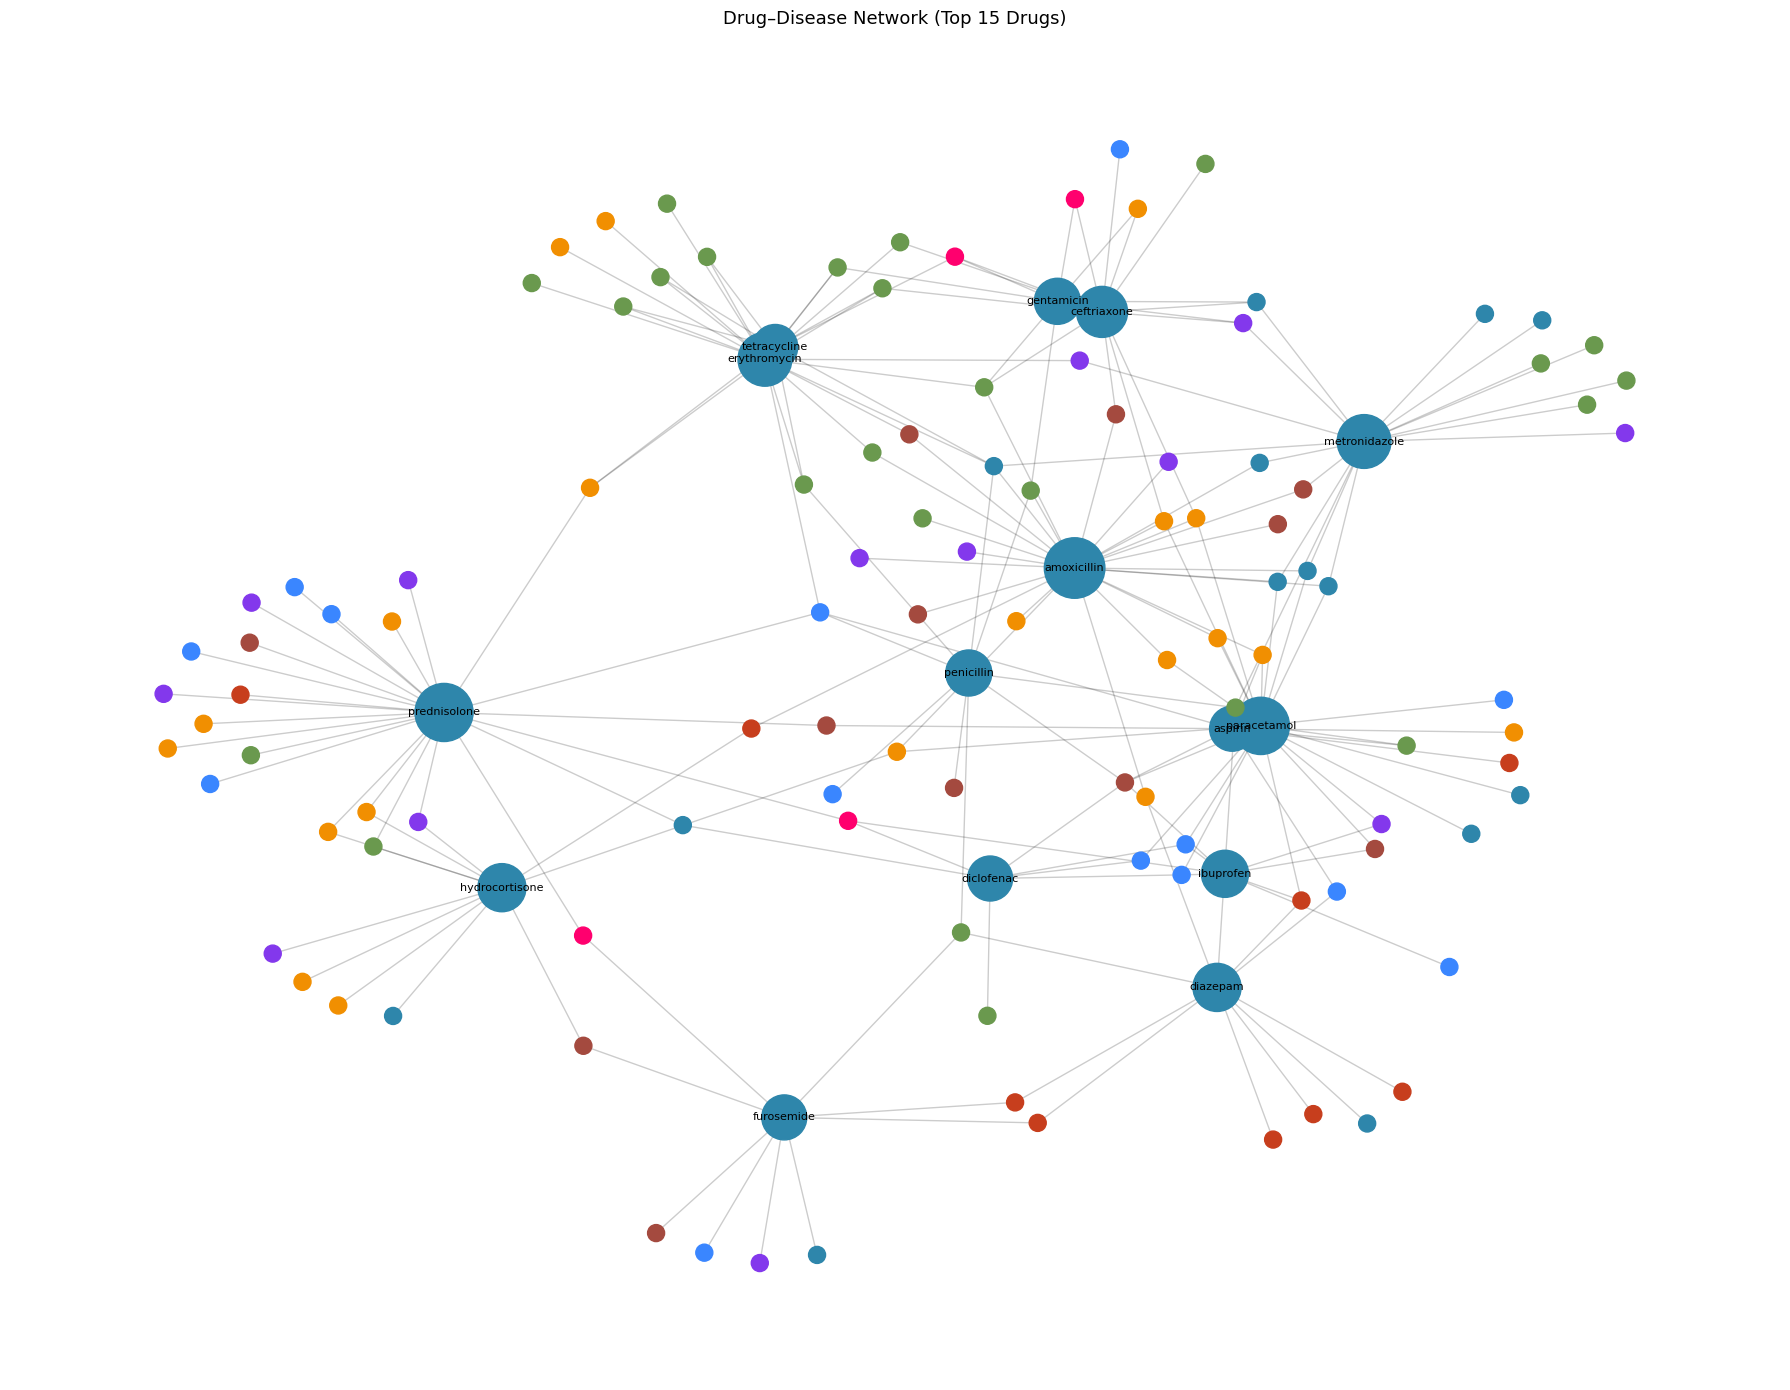

In [32]:
# ── 5. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(18, 14))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_edges(G, pos, alpha=0.2, ax=ax)
nx.draw_networkx_nodes(G, pos,
                       node_color=node_colors,
                       node_size=node_sizes,
                       ax=ax)

# label only drugs
drug_labels = {n: n for n in top_drugs if n in G.nodes}
nx.draw_networkx_labels(G, pos, labels=drug_labels, font_size=8)

ax.set_title("Drug–Disease Network (Top 15 Drugs)", fontsize=13)
ax.axis("off")

# ── 6. Save ───────────────────────────────────────────────────────────────────
plt.tight_layout()
#plt.savefig("nstg_outputs/fig05_drug_disease_network.png")
plt.show()
save(fig, "fig05_drug_disease_network.png")

### Investigating Frequency

In [33]:
# explode() flattens the investigations list column into individual rows,
# then str.strip() removes whitespace, then value_counts() tallies.

inv_freq = (
    df_copy.explode("investigations")["investigations"]
    .dropna()
    .str.strip()
    .value_counts()
    .reset_index()
)

inv_freq.columns = ["Investigation", "Frequency"]

print("Top 20 investigations:")
print(inv_freq.head(20).to_string(index=True))

Top 20 investigations:
                          Investigation  Frequency
0                      Chest radiograph         17
1                            Urinalysis         15
2                      Echocardiography         15
3                                   FBC         13
4                   Electrocardiography         12
5                      Full Blood Count         11
6      Electrolyte, Urea and Creatinine         11
7                         Blood culture         10
8                           FBC and ESR          9
9                 FBC and differentials          9
10    Urea, Electrolytes and Creatinine          6
11                        HIV screening          6
12                 Abdominal ultrasound          6
13                 Liver function tests          6
14                                  LFT          5
15                              CT scan          5
16                                  MRI          5
17  Full Blood Count with differentials          5
18      

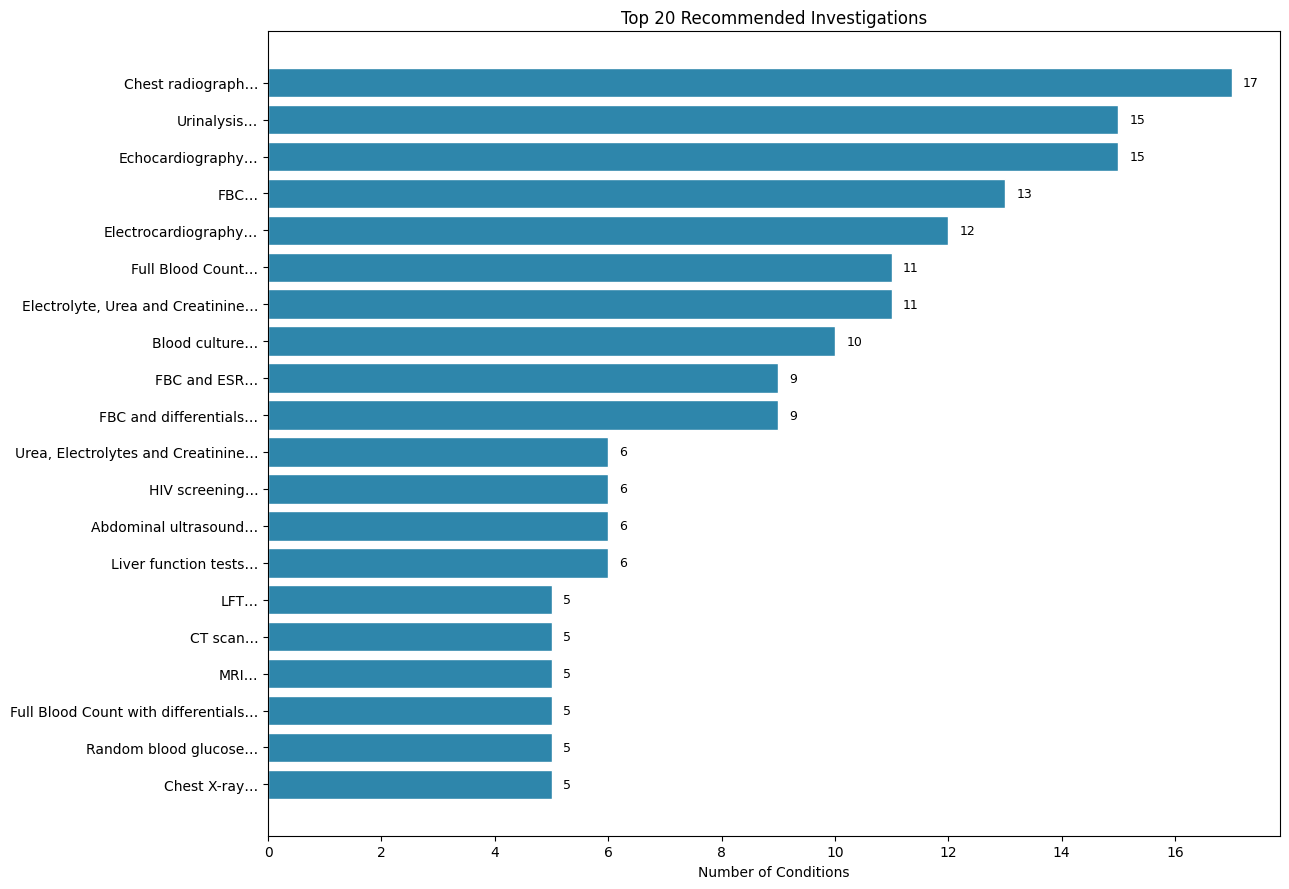

In [34]:
# ── Top 20 investigations ─────────────────────────────────────────────
top20_inv = inv_freq.head(20).copy()

# shorten long labels
top20_inv["Label"] = top20_inv["Investigation"].str.slice(0, 58) + "…"

# ── Plot ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 9))

bars = ax.barh(
    top20_inv["Label"][::-1],
    top20_inv["Frequency"][::-1],
    color="#2E86AB",
    edgecolor="white"
)

# value labels
for bar in bars:
    ax.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        int(bar.get_width()),
        va="center",
        fontsize=9
    )

ax.set_xlabel("Number of Conditions")
ax.set_title("Top 20 Recommended Investigations")

plt.tight_layout()
#plt.savefig("nstg_outputs/fig06_investigations_frequency.png")
plt.show()
save(fig, "fig06_investigations_frequency.png")

### Key Findings

### 1. 🫁 Imaging is Central to Initial Diagnosis  
Chest radiograph (17) is the most frequently recommended investigation, followed by:
- Echocardiography (15)
- Urinalysis (15)
- Chest X-ray (5)
- CT scan (5)
- MRI (5)
- Abdominal ultrasound (6)

👉 This indicates heavy dependence on **basic and intermediate imaging tools**, especially for respiratory, cardiovascular, and abdominal conditions.  
👉 Advanced imaging (CT/MRI) is present but used sparingly, suggesting selective referral in complex cases.

---

### 2. 🧪 Strong Dependence on Routine Laboratory Tests  
Key laboratory investigations include:
- Urinalysis (15)
- Full Blood Count (FBC) variants:
  - FBC (13)
  - Full Blood Count (11)
  - FBC and ESR (9)
  - FBC and differentials (9)
  - Full Blood Count with differentials (5)
- Electrolytes/Urea/Creatinine panels (11, 6)

👉 FBC-related tests dominate overall usage, showing their importance in:
- Infection screening  
- General diagnostic assessment  
- Hematological evaluation  

---

### 3. 🦠 Infectious Disease Surveillance is Prominent  
- Blood culture (10)
- HIV screening (6)

👉 These highlight the continued emphasis on **infectious disease detection and monitoring**, consistent with Nigeria’s epidemiological burden.

---

### 4. ⚠️ Data Quality Issue — Inconsistent Naming of FBC  
A major observation is the fragmentation of Full Blood Count entries:
- FBC  
- Full Blood Count  
- FBC and ESR  
- FBC and differentials  
- Full Blood Count with differentials  

👉 These all represent the same core test but are split into multiple labels.  
👉 If standardized, **FBC would clearly be the most frequently recommended investigation overall**.

---

### 5. 🧭 Tiered Diagnostic Structure  
The dataset reflects a clear diagnostic hierarchy:
- **Primary level:** Urinalysis, FBC, basic blood chemistry  
- **Secondary level:** Ultrasound, ECG, echocardiography  
- **Tertiary level:** CT and MRI  

👉 This aligns with a **cost-sensitive, resource-aware healthcare system** where advanced diagnostics are selectively used.

---

### 📌 Summary  
NSTG 2022 shows a diagnostic framework heavily anchored on **basic laboratory investigations and fundamental imaging tools**, particularly FBC, urinalysis, and chest radiography. While advanced imaging exists, it is less frequently used. A key limitation is inconsistent naming of FBC-related tests, which fragments its true dominance and highlights the need for standardisation in future datasets.

### DIFFERENTIAL DIAGNOSIS OVERLAP NETWORK

In [35]:
# ── Filter conditions with differential diagnoses ─────────────────────────────
df_dd = df_copy[df_copy["has_diff_dx"]].copy()
print(f"Conditions with differential diagnoses: {len(df_dd)}")

# ── Create graph ──────────────────────────────────────────────────────────────
Gd = nx.Graph()

# Add nodes
for _, row in df_dd.iterrows():
    Gd.add_node(row["condition_name"], category=row["category"])

# Add edges based on overlap of ≥2 differential diagnoses
for (i1, r1), (i2, r2) in combinations(df_dd.iterrows(), 2):

    dd1 = set(map(str.lower, r1["differential_diagnoses"]))
    dd2 = set(map(str.lower, r2["differential_diagnoses"]))

    overlap = len(dd1 & dd2)

    if overlap >= 2:
        Gd.add_edge(
            r1["condition_name"],
            r2["condition_name"],
            weight=overlap
        )

print(f"DD Network: {Gd.number_of_nodes()} nodes, {Gd.number_of_edges()} edges")

# ── Degree ranking ────────────────────────────────────────────────────────────
degree_df = (
    pd.DataFrame(Gd.degree(), columns=["Condition", "Degree"])
    .sort_values("Degree", ascending=False)
)

print("Most diagnostically connected conditions:")
print(degree_df.head(10).to_string(index=False))

Conditions with differential diagnoses: 166
DD Network: 162 nodes, 22 edges
Most diagnostically connected conditions:
                                           Condition  Degree
                                           Psoriasis       4
               Chancroid (Ulcus Molle, Soft Chancre)       3
                                            Syphilis       3
                                    Apnea in a Child       3
                             The Unconscious Patient       2
                                       Poliomyelitis       2
                                  Contact Dermatitis       2
                            Urticaria and Angioedema       2
Granuloma Inguinale (Donovanosis Granuloma Venereum)       2
                                    Pityriasis Rosea       2


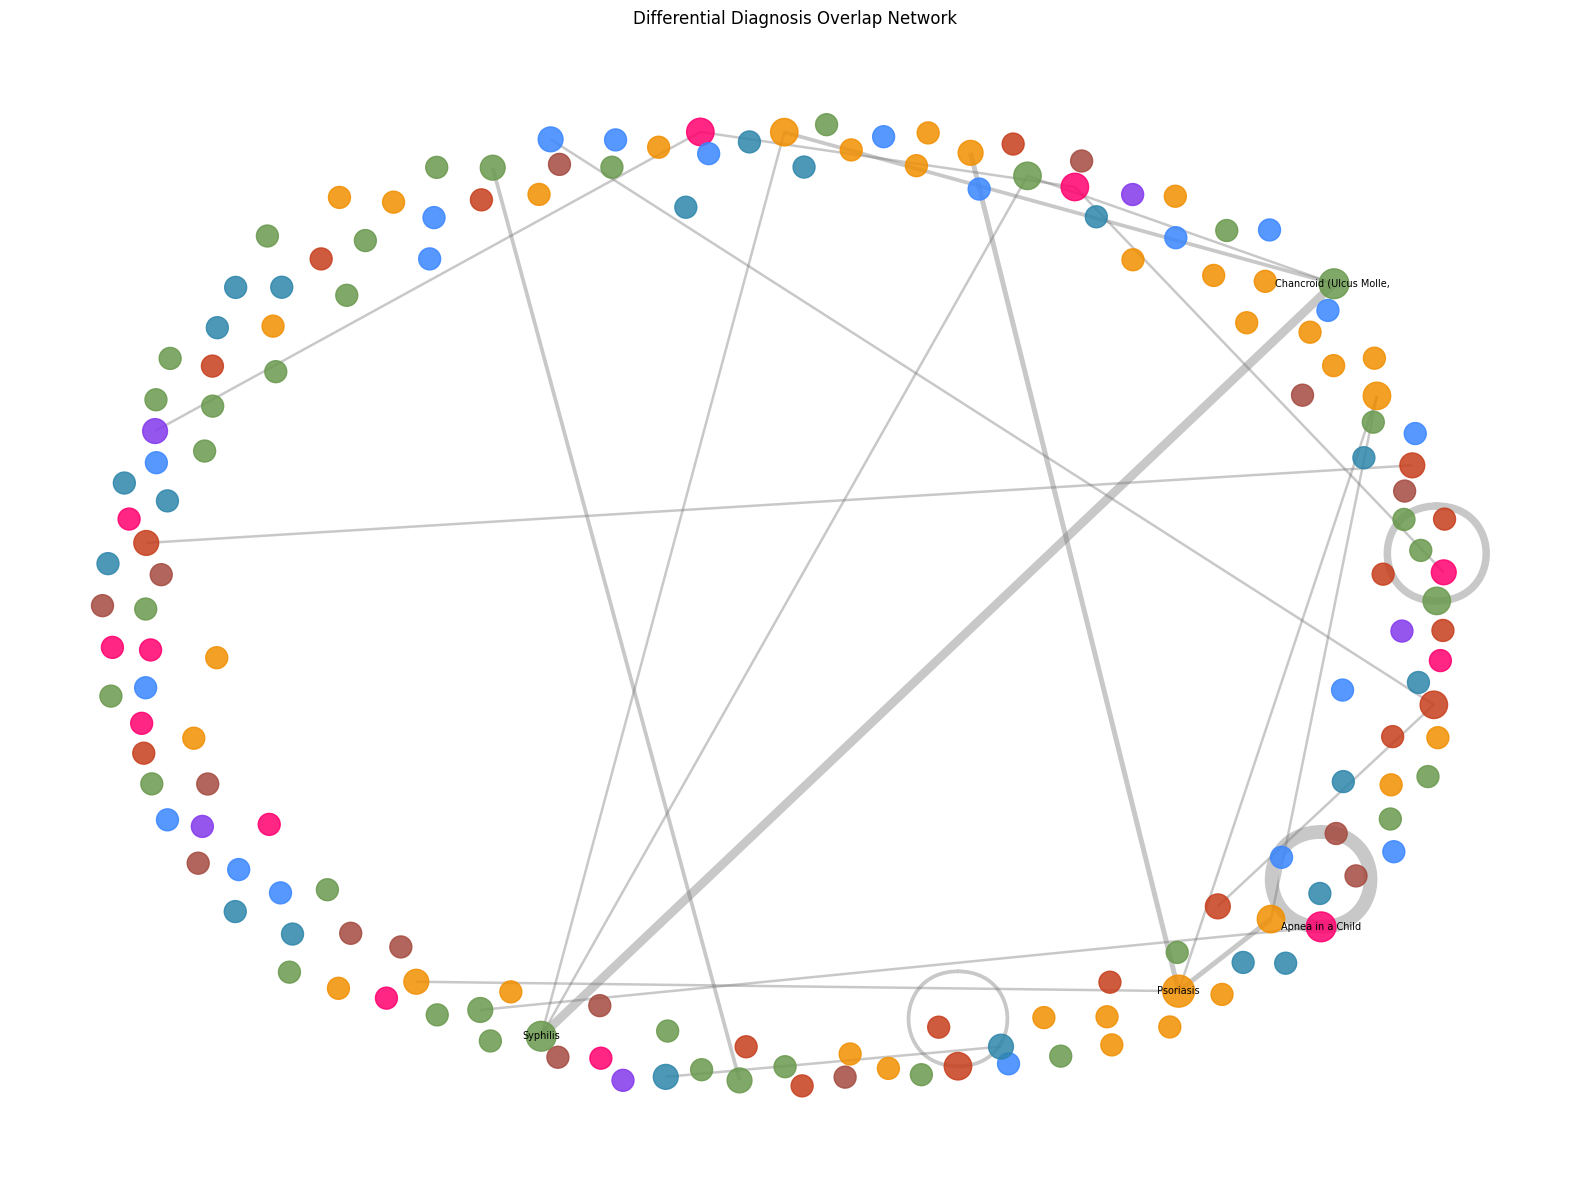

In [36]:
# ── Differential Diagnosis Network Plot ───────────────────────────────────────


degree_dict = dict(Gd.degree())

fig, ax = plt.subplots(figsize=(16, 12))

pos = nx.spring_layout(Gd, k=3.0, seed=7)

cat_color_map = {
    cat: PALETTE[i % len(PALETTE)]
    for i, cat in enumerate(df_copy["category"].dropna().unique())
}

cat_color_map["Other"] = "#AAAAAA"

# edge width = strength of diagnostic overlap
edge_widths = [
    Gd[u][v].get("weight", 1) * 0.9
    for u, v in Gd.edges()
]

# node colors by category
node_colors = [
    cat_color_map.get(Gd.nodes[n].get("category", "Other"), "#AAA")
    for n in Gd.nodes
]

# node sizes = diagnostic connectivity
node_sizes = [
    250 + degree_dict[n] * 70 for n in Gd.nodes
]

nx.draw_networkx_edges(Gd, pos, width=edge_widths, alpha=0.4, edge_color="#777", ax=ax)
nx.draw_networkx_nodes(Gd, pos, node_color=node_colors, node_size=node_sizes, alpha=0.85, ax=ax)

# show labels only for important nodes
labels = {n: n[:24] for n in Gd.nodes if degree_dict[n] >= 3}
nx.draw_networkx_labels(Gd, pos, labels=labels, font_size=7, ax=ax)

ax.set_title("Differential Diagnosis Overlap Network")
ax.axis("off")

plt.tight_layout()
#plt.savefig("nstg_outputs/fig07_differential_diagnosis_network.png")
plt.show()
save(fig, "fig07_differential_diagnosis_network.png")

Psoriasis shows the highest diagnostic connectivity (degree = 4), indicating significant overlap with other dermatological conditions, while STI-related diseases form a tightly connected diagnostic cluster, reflecting real-world challenges in differentiating genital ulcer diseases in clinical practice.

### COMPLICATION BURDEN BY CATEGORY

In [37]:
df_copy.head(3)

,condition_name,condition_slug,source,introduction,clinical_features,investigations,treatment,differential_diagnoses,complications,prevention,...,n_prevention,n_goals,has_introduction,has_prognosis,has_prevention,has_complications,has_diff_dx,category,detected_drugs,n_detected_drugs
0,Abortion,abortion,NSTG 2022,One of the leading causes of morbidity and mor...,"[{'type': 'Threatened Abortion', 'features': [...","[PCV or Hb estimation, Urinalysis, Ultrasound ...","{'goals': ['Restore haemostasis', 'Prevent/tre...","[Ectopic pregnancy, Hydatidiform mole]","[Endometritis, parametritis, peritonitis, haem...",[Promote personal and family understanding of ...,...,3,3,True,False,True,True,True,Maternal/Reproductive,"[misoprostol, oxytocin]",2
1,Acne Vulgaris,acne-vulgaris,NSTG 2022,One of the most common skin diseases. A disord...,"[{'type': 'General', 'features': ['Almost ever...","[Usually, none required, In the presence of un...","{'goals': ['Reduce severity of acne', 'Prevent...","[Acne rosacea, Dermatosis papulosa nigra, Stea...",[Psychosocial problems from cosmetic disfigure...,"[Avoid oil-based cosmetics, hair styling mouss...",...,2,2,True,False,True,True,True,Dermatological,"[doxycycline, erythromycin, prednisolone, spir...",6
2,Acute Abdomen,acute-abdomen,NSTG 2022,These are abdominal conditions causing sudden ...,"[{'type': 'Clinical Evaluation', 'features': [...",[Plain radiography of abdomen: Supine and upri...,"{'goals': ['Achieve good outcome', 'Prevent/mi...","[Detailed in Table 16.2, list of possible causes]",[],[],...,0,2,True,True,False,False,True,Surgical/Emergency,[],0


In [38]:
# ── Flatten complications list ─────────────────────────────
comp_long = df_copy.explode("complications").dropna(subset=["complications"])
comp_long["complications"] = comp_long["complications"].str.strip()

# ── Group by category ───────────────────────────────────────
comp_cat = comp_long.groupby("category").agg(
    total_complications=("complications", "count"),
    n_conditions=("condition_name", "nunique")
).reset_index()

# ── Compute average complications per condition ─────────────
comp_cat["avg_per_condition"] = (
    comp_cat["total_complications"] / comp_cat["n_conditions"]
).round(2)

# ── Sort and display ────────────────────────────────────────
comp_cat = comp_cat.sort_values("avg_per_condition", ascending=False)

print(comp_cat)

                    category  total_complications  n_conditions  \
7             Haematological                   57             5   
4        Endocrine/Metabolic                   33             5   
8        Infectious/Tropical                  192            33   
18        Surgical/Emergency                   20             4   
16          Renal/Urological                   51            11   
9      Maternal/Reproductive                   54            12   
17               Respiratory                   40             9   
5           Gastrointestinal                   34             8   
11       Neurological/Mental                   58            14   
1         Dental/Oral Health                   23             6   
13                  Oncology                   23             6   
6                  Geriatric                    7             2   
12               Nutritional                    7             2   
0             Cardiovascular                   45            1

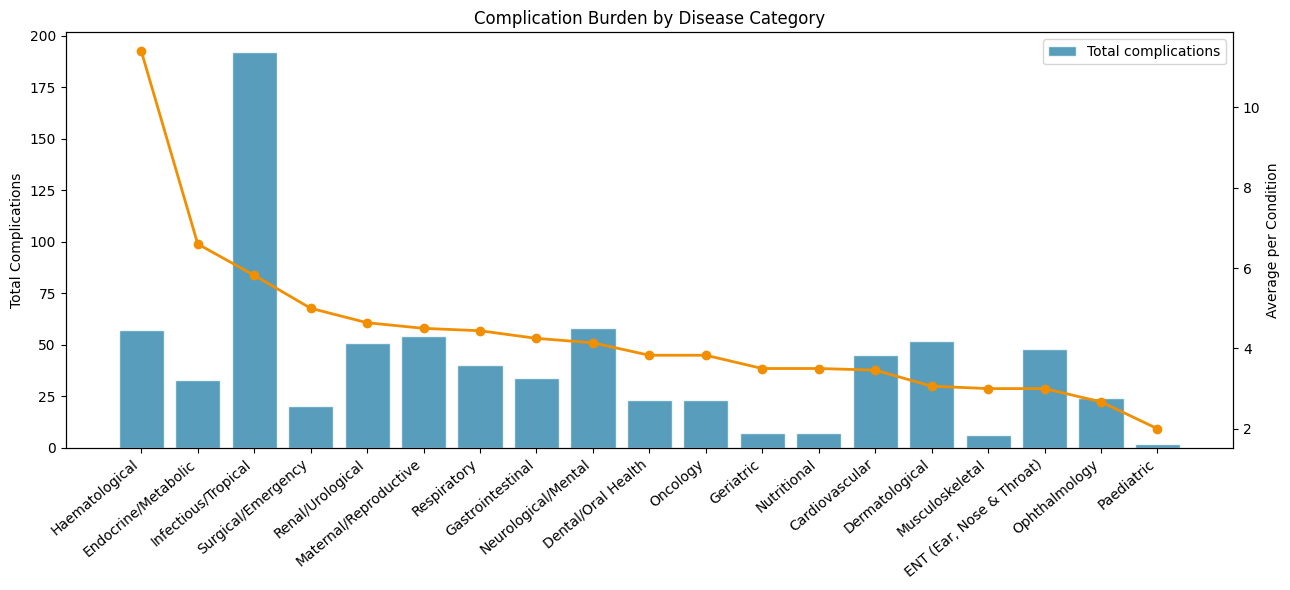

In [39]:
# ── Plot setup ─────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 6))
ax2 = ax1.twinx()

x = np.arange(len(comp_cat))

# ── Bar: total complications ───────────────────────────────
ax1.bar(
    x,
    comp_cat["total_complications"],
    color="#2E86AB",
    alpha=0.8,
    edgecolor="white",
    label="Total complications"
)

# ── Line: average per condition ────────────────────────────
ax2.plot(
    x,
    comp_cat["avg_per_condition"],
    color="#F18F01",
    marker="o",
    linewidth=2,
    label="Avg per condition"
)

# ── X-axis labels ──────────────────────────────────────────
ax1.set_xticks(x)
ax1.set_xticklabels(comp_cat["category"], rotation=40, ha="right")

# ── Labels and title ───────────────────────────────────────
ax1.set_ylabel("Total Complications")
ax2.set_ylabel("Average per Condition")
ax1.set_title("Complication Burden by Disease Category")

# ── Legend ─────────────────────────────────────────────────
ax1.legend(loc="upper right")

# ── Save ───────────────────────────────────────────────────
plt.tight_layout()
#plt.savefig("nstg_outputs/fig8_complication_burden.png")
plt.show()
save(fig, "fig08_complication_burden.png")

### DRUG vs NON-DRUG INTERVENTION RATIO

In [40]:
# ── Average drug and non-drug treatments per category ─────
ratio_df = (
    df_copy.groupby("category")[["n_drug_items", "n_nondrug_items"]]
    .mean()
    .reset_index()
)

# Rename columns
ratio_df.columns = [
    "Category",
    "Avg_Drug",
    "Avg_NonDrug"
]

# ── Drug dominance ratio ──────────────────────────────────
ratio_df["Drug_Dominance"] = (
    ratio_df["Avg_Drug"] /
    ratio_df["Avg_NonDrug"].replace(0, 0.01)
).round(2)

# ── Sort highest drug use first ───────────────────────────
ratio_df = ratio_df.sort_values("Avg_Drug", ascending=False)

print(ratio_df)

                    Category  Avg_Drug  Avg_NonDrug  Drug_Dominance
7             Haematological  7.454545     4.181818            1.78
18               Respiratory  7.000000     1.666667            4.20
10           Musculoskeletal  6.818182     3.090909            2.21
0             Cardiovascular  5.750000     2.250000            2.56
3   ENT (Ear, Nose & Throat)  5.562500     2.687500            2.07
8        Infectious/Tropical  5.317073     2.073171            2.56
11       Neurological/Mental  5.125000     3.187500            1.61
2             Dermatological  4.950000     2.400000            2.06
14             Ophthalmology  4.600000     0.400000           11.50
13                  Oncology  4.222222     1.500000            2.81
19        Surgical/Emergency  3.750000     6.125000            0.61
16                Paediatric  3.714286     3.000000            1.24
9      Maternal/Reproductive  3.500000     4.750000            0.74
1         Dental/Oral Health  3.166667     2.722

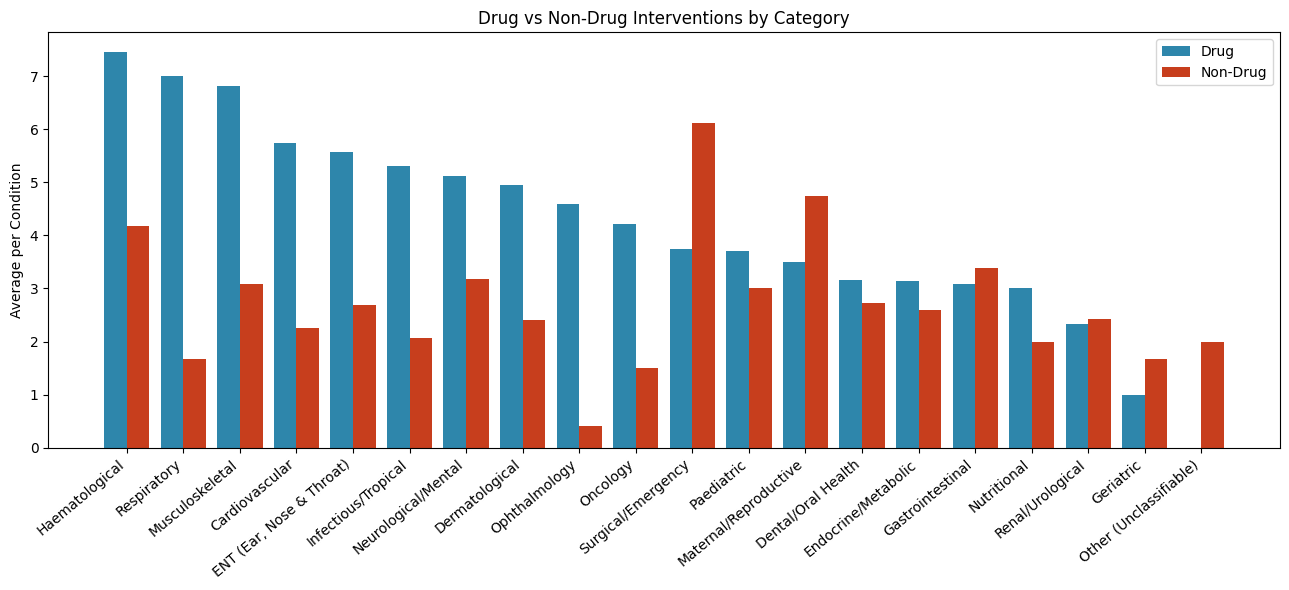

In [41]:
# ── Create chart ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

x = np.arange(len(ratio_df))

# Drug bars
ax.bar(
    x - 0.2,
    ratio_df["Avg_Drug"],
    width=0.4,
    label="Drug",
    color="#2E86AB"
)

# Non-drug bars
ax.bar(
    x + 0.2,
    ratio_df["Avg_NonDrug"],
    width=0.4,
    label="Non-Drug",
    color="#C73E1D"
)

# Labels
ax.set_xticks(x)
ax.set_xticklabels(ratio_df["Category"], rotation=40, ha="right")

ax.set_ylabel("Average per Condition")
ax.set_title("Drug vs Non-Drug Interventions by Category")

# Legend
ax.legend()

# Save
plt.tight_layout()
#plt.savefig("nstg_outputs/fig9_drug_vs_nondrug.png")
plt.show()
save(fig, "fig09_drug_vs_nondrug.png")

### PREVENTION ANALYSIS

In [42]:
# Split prevention lists into separate rows
prev = (
    df_copy.explode("prevention")
      .dropna(subset=["prevention"])
)

# Convert to lowercase
prev["text"] = prev["prevention"].str.lower()

# Simple classification function
def get_theme(text):

    if "vaccin" in text or "immun" in text:
        return "Vaccination"

    elif "hygiene" in text or "wash" in text or "clean" in text:
        return "Hygiene"

    elif "diet" in text or "nutrition" in text:
        return "Nutrition"

    elif "exercise" in text or "lifestyle" in text:
        return "Lifestyle"

    elif "screen" in text or "test" in text:
        return "Screening"

    elif "condom" in text or "safe sex" in text:
        return "Safe Sex"

    else:
        return "Other Preventive Measures"

# Apply classification
prev["Theme"] = prev["text"].apply(get_theme)

# Count themes
theme_counts = prev["Theme"].value_counts().reset_index()
theme_counts.columns = ["Theme", "Count"]

print(theme_counts)

# Coverage
with_prev = df_copy["has_prevention"].sum()

print(f"\nConditions with prevention: {with_prev}")
coverage = (with_prev / len(df_copy)) * 100
print(f"Coverage: {round(coverage, 1)}%")

                       Theme  Count
0  Other Preventive Measures    334
1                Vaccination     46
2                    Hygiene     26
3                  Nutrition     16
4                  Screening     14
5                   Safe Sex      9
6                  Lifestyle      8

Conditions with prevention: 155
Coverage: 57.4%


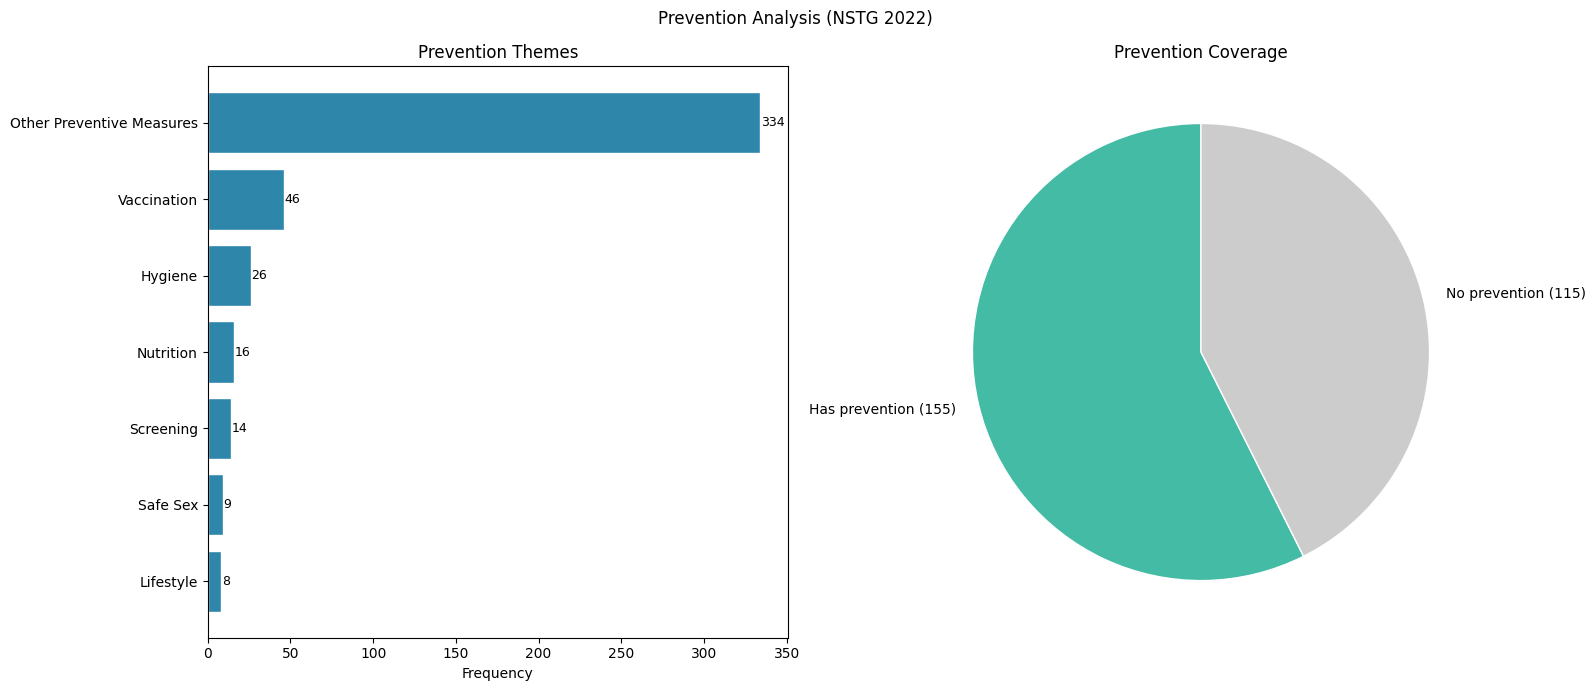

In [43]:
with_prev = df_copy["has_prevention"].sum()
without_prev = len(df_copy) - with_prev

sizes = [with_prev, without_prev]

# ── FIGURE ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── 1. Theme bar chart ─────────────────────────────────
axes[0].barh(
    theme_counts["Theme"][::-1],
    theme_counts["Count"][::-1],
    color="#2E86AB",
    edgecolor="white"
)

# Add value labels
for i, val in enumerate(theme_counts["Count"][::-1]):
    axes[0].text(val + 0.5, i, str(val), va="center", fontsize=9)

axes[0].set_title("Prevention Themes")
axes[0].set_xlabel("Frequency")

# ── 2. Coverage donut chart ────────────────────────────
sizes = [with_prev, without_prev]

labels = [
    f"Has prevention ({with_prev})",
    f"No prevention ({without_prev})"
]

axes[1].pie(
    sizes,
    labels=labels,
    colors=["#44BBA4", "#CCCCCC"],
    startangle=90,
    wedgeprops={"edgecolor": "white"}
)

axes[1].set_title("Prevention Coverage")

plt.suptitle("Prevention Analysis (NSTG 2022)")
plt.tight_layout()
#plt.savefig("nstg_outputs/fig10_prevention_analysis.png")
plt.show()
save(fig, "fig10_prevention_analysis.png")

### TF-IDF CLINICAL FEATURE KEYWORD EXTRACTION

In [44]:
# Convert clinical features into one text string
def extract_clinical_text(cf_list):

    parts = []

    # Go through each item
    for item in cf_list:

        # If item is a dictionary
        if isinstance(item, dict):

            # Add all features
            parts.extend(item.get("features", []))

        # If item is already text
        elif isinstance(item, str):

            parts.append(item)

    # Join everything into one sentence
    return " ".join(parts)


# Create new column with clean text
df_copy["clinical_text"] = df_copy["clinical_features"].apply(extract_clinical_text)


# ---------------------------------------------------
# Combine all clinical text by disease category
# ---------------------------------------------------

cat_text_df = (

    df_copy.groupby("category")["clinical_text"]

    # Merge all text into one document per category
    .apply(lambda texts: " ".join(t for t in texts if t.strip()))

    .reset_index()

)

# Remove categories with very little text
cat_text_df = cat_text_df[
    cat_text_df["clinical_text"].str.len() > 50
].copy()


# ---------------------------------------------------
# Common words to ignore
# ---------------------------------------------------

STOP = {

    "the","and","of","or","in","with","a","to","is","may",
    "be","are","by","from","for","on","at","as","an","that",
    "this","its","which","also","can","have","not","other",
    "more","some","when","usually","often","most","both",
    "after","before","should","patient","patients","due","include"

}


# ---------------------------------------------------
# Create TF-IDF model
# ---------------------------------------------------

tfidf = TfidfVectorizer(

    max_features=200,      # Keep top 200 terms
    stop_words=list(STOP), # Ignore common words
    ngram_range=(1, 2),    # Use single + two-word phrases
    min_df=1

)


# Convert text into TF-IDF matrix
tfidf_matrix = tfidf.fit_transform(cat_text_df["clinical_text"])

# Get all detected keywords
feature_names = tfidf.get_feature_names_out()


# ---------------------------------------------------
# Print top keywords for each category
# ---------------------------------------------------

print("Top TF-IDF terms per category:")

for i, row in cat_text_df.iterrows():

    # Get TF-IDF scores
    scores = tfidf_matrix[i].toarray().flatten()

    # Get indexes of highest scores
    top_idx = scores.argsort()[-6:][::-1]

    # Convert indexes into words
    terms = [feature_names[j] for j in top_idx]

    # Print result
    print(f"  {row['category']}: {', '.join(terms)}")

Top TF-IDF terms per category:
  Cardiovascular: chest, chest pain, pain, dyspnoea, failure, swelling
  Dental/Oral Health: ulcers, pain, 10, days, mouth, associated
  Dermatological: lesions, pruritus, skin, papules, erythematous, face
  ENT (Ear, Nose & Throat): ear, discharge, nasal, pain, sore, sore throat
  Endocrine/Metabolic: kg, weight, diabetes, loss, increased, poor
  Gastrointestinal: jaundice, abdominal, life, days, day, within
  Geriatric: physical, etc, loss, weight loss, weight, activity
  Haematological: bone, crisis, haemorrhage, cell, anaemia, blood
  Infectious/Tropical: diarrhoea, lesions, days, fever, rash, skin
  Maternal/Reproductive: weeks, contact, history, vaginal, pregnancy, women
  Musculoskeletal: joint, back, back pain, pain, associated, rash
  Neurological/Mental: sleep, signs, headache, pain, sudden, brain
  Nutritional: bone, dry, anaemia, hair, skin, increased
  Oncology: weight loss, vaginal, weight, bone, pain, haemorrhage
  Ophthalmology: eye, red, 

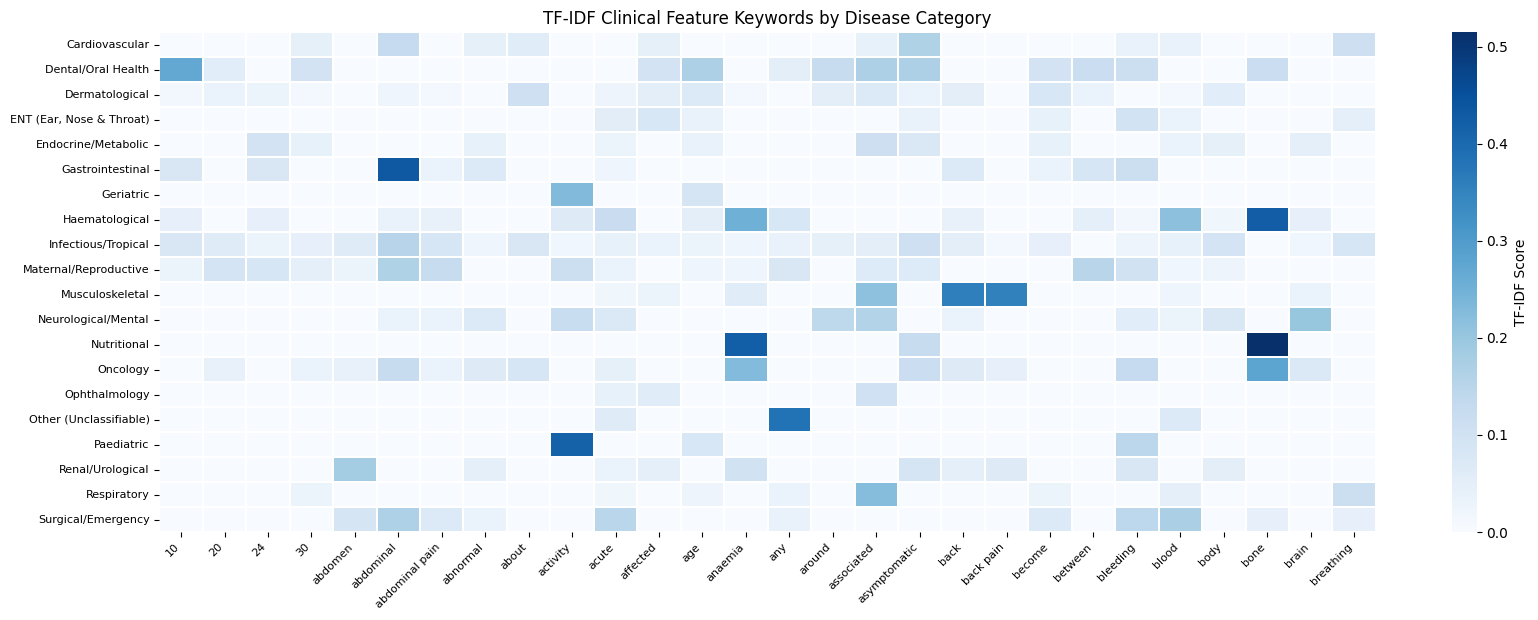

In [45]:
# Get all category documents
docs = cat_text_df["clinical_text"].tolist()

common_terms = []

# Check each keyword
for term in feature_names:

    # Count how many documents contain the term
    count = sum(term in doc for doc in docs)

    # Keep terms appearing in 3 or more categories
    if count >= 3:
        common_terms.append(term)

# Keep only first 28 terms
common_terms = common_terms[:28]


# ---------------------------------------------------
# Get indexes of selected keywords
# ---------------------------------------------------

common_idx = [

    list(feature_names).index(term)

    for term in common_terms
]


# ---------------------------------------------------
# Create smaller TF-IDF matrix
# ---------------------------------------------------

sub_matrix = tfidf_matrix[:, common_idx].toarray()


# ---------------------------------------------------
# Convert to dataframe for heatmap
# ---------------------------------------------------

hm_df = pd.DataFrame(

    sub_matrix,

    index=cat_text_df["category"].tolist(),

    columns=common_terms
)


# ---------------------------------------------------
# Create heatmap
# ---------------------------------------------------

fig, ax = plt.subplots(figsize=(17, 7))

sns.heatmap(

    hm_df,

    cmap="Blues",

    linewidths=0.3,

    cbar_kws={"label": "TF-IDF Score"},

    ax=ax
)


# ---------------------------------------------------
# Chart formatting
# ---------------------------------------------------

ax.set_title(

    "TF-IDF Clinical Feature Keywords by Disease Category"

)

plt.xticks(

    rotation=45,

    ha="right",

    fontsize=8
)

plt.yticks(

    rotation=0,

    fontsize=8
)


# ---------------------------------------------------
# Final layout and save figure
# ---------------------------------------------------

plt.tight_layout(rect=[0, 0.1, 1, 1])

plt.show()
save(fig, "fig11_tfidf_heatmap.png")

### WORD CLOUD

In [46]:
all_intro_text = (

    df_copy[df_copy["has_introduction"]]["introduction"]

    .str.cat(sep=" ")

)


# ---------------------------------------------------
# Extra words to ignore in the word cloud
# ---------------------------------------------------

stopwords_extra = {

    "may", "also", "due", "used", "common", "usually",
    "often", "associated", "caused", "cause", "cases",
    "include", "known", "however", "patient", "patients",
    "disease", "condition", "treatment", "Nigeria",
    "characterized", "type"

}


# ---------------------------------------------------
# Create word cloud
# ---------------------------------------------------

wc_full = WordCloud(

    width=1400,
    height=700,

    background_color="white",

    colormap="tab20",

    max_words=200,

    stopwords=stopwords_extra,

    collocations=True

).generate(all_intro_text)

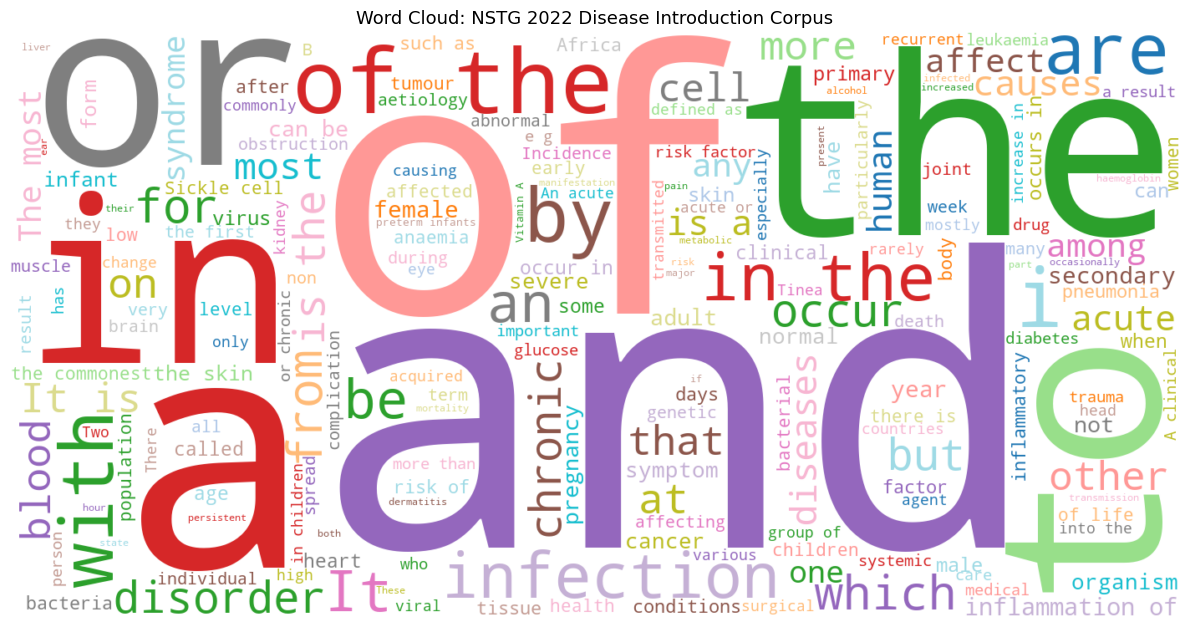

In [47]:
# Create figure

fig, ax = plt.subplots(figsize=(14, 7))


# ---------------------------------------------------
# Display word cloud
# ---------------------------------------------------

ax.imshow(

    wc_full,

    interpolation="bilinear"
)


# Remove axes
ax.axis("off")


# ---------------------------------------------------
# Add chart title
# ---------------------------------------------------

ax.set_title(

    "Word Cloud: NSTG 2022 Disease Introduction Corpus",

    fontsize=13
)


# Adjust layout and save figure

plt.tight_layout(rect=[0, 0.09, 1, 1])

plt.show()

save(fig, "fig12_wordcloud.png")

### Exporting for Power BI Dashboard

In [43]:
# Table 1: Master Condition table
master = df_copy[[
    "condition_name", "condition_slug", "source", "category",
    "n_drug_items", "n_nondrug_items", "n_investigations",
    "n_complications", "n_diff_dx", "n_prevention",
    "n_detected_drugs", "has_introduction", "has_prognosis",
    "has_prevention", "has_complications", "has_diff_dx"
]].copy()
master.to_csv("nstg_powerbi_exports/01_master_condition.csv", index=False)
print(f"  01_master_conditions.csv — {len(master)} rows")

  01_master_conditions.csv — 270 rows


In [44]:
# Table 2: Drug–Condition mapping
drug_long_export = (
    df_copy[["condition_name", "category", "detected_drugs"]]
    .explode("detected_drugs")
    .dropna(subset=["detected_drugs"])
    .rename(columns={"detected_drugs": "drug_name"})
    .reset_index(drop=True)
)

drug_long_export.to_csv(f"nstg_powerbi_exports/02_drugs_long.csv", index=False)
print(f"  02_drugs_long.csv — {len(drug_long_export)} rows")

  02_drugs_long.csv — 380 rows


In [45]:
# Table 3: Drug frequency summary
drug_freq.to_csv(f"nstg_powerbi_exports/03_drug_frequency.csv", index=False)
print(f"  03_drug_frequency.csv — {len(drug_freq)} rows")

  03_drug_frequency.csv — 68 rows


In [46]:
# Table 4: Investigation–Condition mapping
inv_export = (
    df_copy[["condition_name", "category"]]
    .join(df_copy["investigations"].explode().rename("investigation"))
    .dropna(subset=["investigation"])
    .assign(investigation=lambda x: x["investigation"].str.strip())
    .reset_index(drop=True)
)
inv_export.to_csv(f"nstg_powerbi_exports/04_investigations_long.csv", index=False)
print(f"  04_investigations_long.csv — {len(inv_export)} rows")

  04_investigations_long.csv — 1132 rows


In [47]:
# Table 5: Complication–Condition mapping
comp_export = (
    df_copy[["condition_name", "category"]]
    .join(df_copy["complications"].explode().rename("complication"))
    .dropna(subset=["complication"])
    .assign(complication=lambda x: x["complication"].str.strip())
    .reset_index(drop=True)
)
comp_export.to_csv(f"nstg_powerbi_exports/05_complications_long.csv", index=False)
print(f"  05_complications_long.csv — {len(comp_export)} rows")

  05_complications_long.csv — 776 rows


In [48]:
# Table 6: Prevention–Condition mapping
prev_export = prev[["condition_name", "category", "prevention", "Theme"]].reset_index(drop=True)
prev_export.to_csv(f"nstg_powerbi_exports/06_prevention_long.csv", index=False)
print(f"  06_prevention_long.csv — {len(prev_export)} rows")

  06_prevention_long.csv — 453 rows


In [49]:
# ── Also export category and completeness summaries ──────────────────────────
cat_counts.to_csv(f"nstg_powerbi_exports/07_category_summary.csv", index=False)
completeness.to_csv(f"nstg_powerbi_exports/08_completeness_audit.csv", index=False)
comp_cat.to_csv(f"nstg_powerbi_exports/09_complication_by_category.csv", index=False)
ratio_df.to_csv(f"nstg_powerbi_exports/10_drug_vs_nondrug_by_category.csv", index=False)
print(f"  07–10: summary tables exported")


  07–10: summary tables exported


### © [Adeoye Samuel] 2025 · CC BY 4.0
### Original analysis of NSTG 2022 — Nigeria Standard Treatment Guidelines
### Repository: [[your GitHub UR](https://github.com/Sammyregt/nstg-2022-clinical-guidelines-analysis.git)L]
### Cite as: [Adeoye] (2026). NSTG 2022 Clinical Guidelines Analysis.
### GitHub. https://github.com/Sammyregt/nstg-2022-clinical-guidelines-analysis.git